<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2024-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1

## Starting Point for Exercise 1, part I

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part I.

One of the goals of this exercise is to get you acquainted with sklearn and related libraries like pandas and numpy. You will probably need to consult the documentation of those libraries:
- sklearn: [Documentation](https://scikit-learn.org/stable/user_guide.html)
- Pandas: [Documentation](https://pandas.pydata.org/docs/#)
- NumPy: [Documentation](https://numpy.org/doc/)
- SHAP: [Documentation](https://shap.readthedocs.io/en/latest/index.html)

## Task Description

Follow the instructions in this notebook to:

1. Explore the data and create training/test splits for your experiments

2. Build a LogisticRegression classifier and design some relevant features to apply it to your data

3. Conduct hyperparameter tuning to find the optimal hyperparameters for your model

4. Explore your model's predictions and conduct an error analysis to see where the model fails

5. Conduct an interpretability analysis, investigating the model's most important features.

6. Conduct an ablation study using a subset of languages


Throughout the notebook, there are questions that you should address in your report. These are marked with 📝❓ and are collected again in the lab report section at the end of the notebook.

☝ Note, these questions are intended to provide you with an opportunity to reflect on what it is that you are doing and the kind of challenges you might face along the way.

## Use of generative AI

AI tools may be used in this exercise to help you explain code, debug, improve documentation, and explore alternatives. Any use must be documented in the *Declaration on the use of AI* at the end of this notebook (which tools were used and for which purposes). You remain responsible for understanding, checking, and testing everything you submit, and you must be able to explain any submitted text, code, analyses, and AI-assisted contributions. See the [CL guidelines on academic integrity and AI use](https://www.cl.uzh.ch/en/Studies/Services/academic-integrity.html).

In [ ]:
# Pin the library versions used in this course (the same ones as in the W03 tutorial),
# so that your notebook runs the same way for you and for your reviewers.
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='Glyph .* missing from font')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

%pip install -q scikit-learn==1.9.1 shap==0.52.0 gdown

import sklearn, shap
print(f"scikit-learn {sklearn.__version__} | shap {shap.__version__}")

Note: you may need to restart the kernel to use updated packages.
scikit-learn 1.9.1 | shap 0.52.0


In [3]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

### Loading the datasets

In [ ]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

In [4]:
with open(f'x_train.txt') as f:
    x_train = f.read().splitlines()
with open(f'y_train.txt') as f:
    y_train = f.read().splitlines()
with open(f'x_test.txt') as f:
    x_test = f.read().splitlines()
with open(f'y_test.txt') as f:
    y_test = f.read().splitlines()

In [6]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Write train_df to csv with tab as separator
train_df.to_csv('train_df.csv', index=False, sep='\t')
# Comibne x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


In [7]:
# Get list of all labels
labels = train_df['label'].unique().tolist()
print(labels)

['est', 'swe', 'mai', 'oci', 'tha', 'orm', 'lim', 'guj', 'pnb', 'zea', 'krc', 'hat', 'pcd', 'tam', 'vie', 'pan', 'szl', 'ckb', 'fur', 'wuu', 'arz', 'ton', 'eus', 'map-bms', 'glk', 'nld', 'bod', 'jpn', 'arg', 'srd', 'ext', 'sin', 'kur', 'che', 'tuk', 'pag', 'tur', 'als', 'koi', 'lat', 'urd', 'tat', 'bxr', 'ind', 'kir', 'zh-yue', 'dan', 'por', 'fra', 'ori', 'nob', 'jbo', 'kok', 'amh', 'khm', 'hbs', 'slv', 'bos', 'tet', 'zho', 'kor', 'sah', 'rup', 'ast', 'wol', 'bul', 'gla', 'msa', 'crh', 'lug', 'sun', 'bre', 'mon', 'nep', 'ibo', 'cdo', 'asm', 'grn', 'hin', 'mar', 'lin', 'ile', 'lmo', 'mya', 'ilo', 'csb', 'tyv', 'gle', 'nan', 'jam', 'scn', 'be-tarask', 'diq', 'cor', 'fao', 'mlg', 'yid', 'sme', 'spa', 'kbd', 'udm', 'isl', 'ksh', 'san', 'aze', 'nap', 'dsb', 'pam', 'cym', 'srp', 'stq', 'tel', 'swa', 'vls', 'mzn', 'bel', 'lad', 'ina', 'ava', 'lao', 'min', 'ita', 'nds-nl', 'oss', 'kab', 'pus', 'fin', 'snd', 'kaa', 'fas', 'cbk', 'cat', 'nci', 'mhr', 'roa-tara', 'frp', 'ron', 'new', 'bar', 'ltg'


### 1.1 Exploring the training data

📝❓Take a look at a couple of texts from different languages and answer the following questions:

1. Do you notice anything that might be challenging for the classification?
2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)
3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.


Q1: Challenges
- Some labels are for sure wrong
- Closely related languages and dialects
- Mixed-language text
- Languages written without spaces
- Very uneven lengths -- shorter text is harder to classify
- The same text under different labels e.g. ava/pcd, hsb/dsb, hin/nep
- 235 classes is a lot for a logistic regression.

Q2: Distributions
- the train and test have roughly the same distributions in word count (separated by space) and character count tested statistically

Q3: Is the split appropriate?
- Overlap between train and test: 3,147 test texts also appear in train. They are concentrated in a few languages: che 449 of 500, hat 407, new 324, pam 290, min 160.
- The 50/50 split wastes training data. 

In [8]:
train_df.value_counts('label')

label
est    500
swe    500
mai    500
oci    500
tha    500
      ... 
ell    500
lij    500
hau    500
mkd    500
ltz    500
Name: count, Length: 235, dtype: int64

In [9]:
test_df.value_counts('label')

label
mwl    500
nld    500
ava    500
tcy    500
bjn    500
      ... 
ton    500
nso    500
roh    500
udm    500
ckb    500
Name: count, Length: 235, dtype: int64

In [10]:
test_df[test_df['label'] == 'tha'].head(5)

,text,label
608,วันที่ 19 มีนาคม มิก-23ยูบี ถูกยิงตกระหว่างยุท...,tha
648,จอมพลไรช์ แฮร์มันน์ วิลเฮล์ม เกอริง (เยอรมัน: ...,tha
1052,นายตำรวจลูกน้องของสารวัตรอาเคจิ เคนโมจิเป็นนาย...,tha
1345,สำนักวิชาทรัพยากรการเกษตร จุฬาลงกรณ์มหาวิทยาลั...,tha
1528,เดิมเทศบาลตำบลระแหง คือ สุขาภิบาลตำบลระแหง ซึ่...,tha


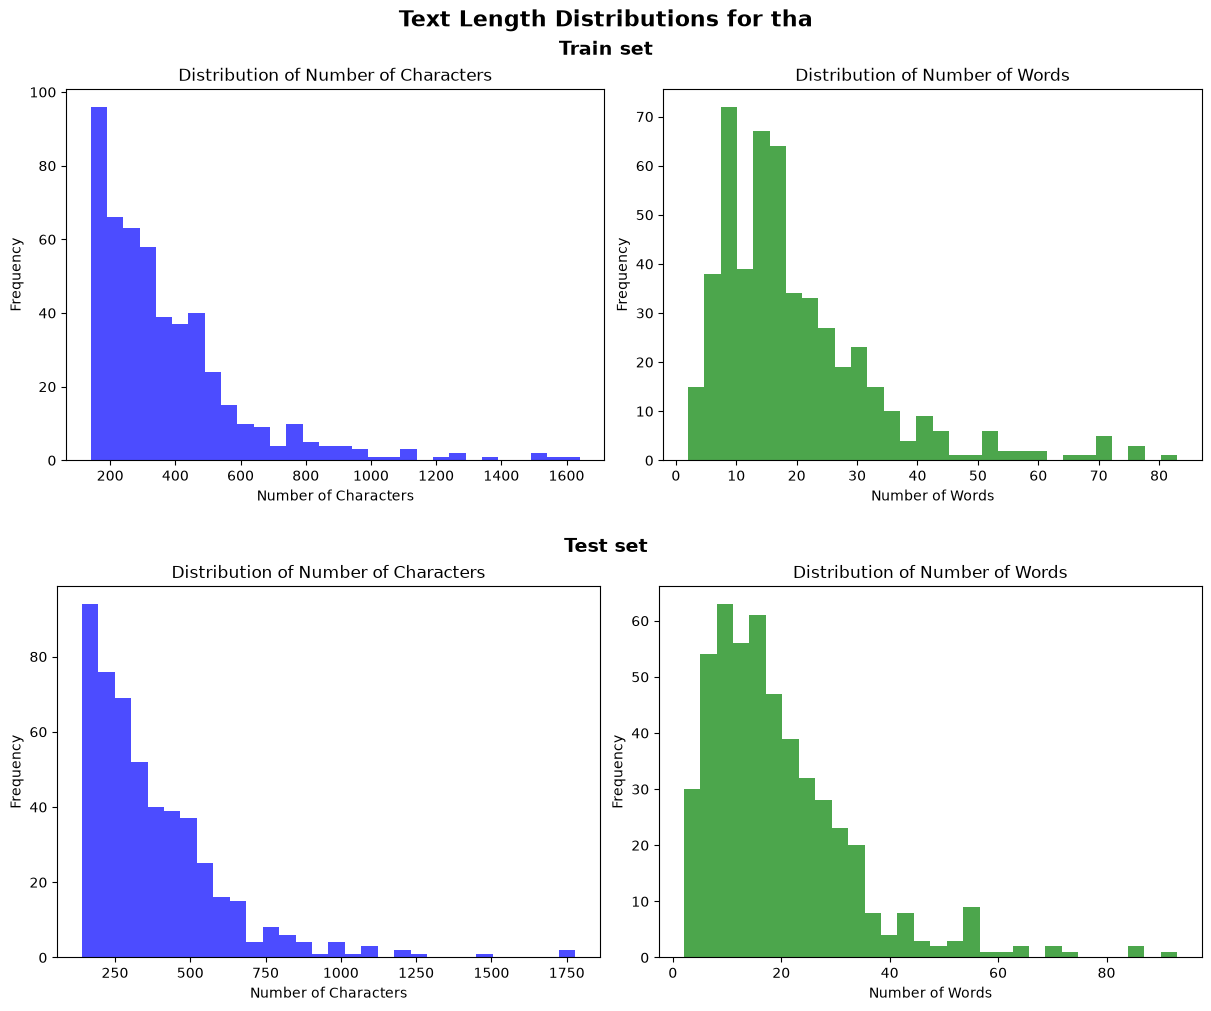

In [13]:
# plot the distribution of number of characters and number of words in the text column for a particular label
# first row: train_df, second row: test_df
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Hiragino Sans', 'Arial Unicode MS', 'DejaVu Sans']

label = 'tha'
splits = {'train': train_df, 'test': test_df}

fig = plt.figure(figsize=(12, 10), layout='constrained')
fig.suptitle(f'Text Length Distributions for {label}', fontsize=16, fontweight='bold')
subfigs = fig.subfigures(2, 1, hspace=0.05)
for subfig, (split_name, df) in zip(subfigs, splits.items()):
    label_df = df[df['label'] == label]
    subfig.suptitle(f'{split_name.capitalize()} set', fontsize=14, fontweight='bold')
    axs = subfig.subplots(1, 2)

    axs[0].hist(label_df['text'].str.len(), bins=30, color='blue', alpha=0.7)
    axs[0].set_title('Distribution of Number of Characters')
    axs[0].set_xlabel('Number of Characters')
    axs[0].set_ylabel('Frequency')

    axs[1].hist(label_df['text'].str.split().str.len(), bins=30, color='green', alpha=0.7)
    axs[1].set_title('Distribution of Number of Words')
    axs[1].set_xlabel('Number of Words')
    axs[1].set_ylabel('Frequency')

plt.show()

We can test if the distribution between train and test are the same in each language (since we already know there are 500 examples for each language)
1. compare distribution of number of characters and number of words (in each example)
2. compare the character frequency distribution (in the whole dataset)

In [14]:
# statistical test: does each language have the same length distribution in train and test?
# two-sample Kolmogorov-Smirnov test per label, for character count and word count (split on spaces)
# H0: train and test lengths come from the same distribution
from scipy.stats import ks_2samp

length_measures = {
    'chars': lambda s: s.str.len(),
    'words': lambda s: s.str.split().str.len(),
}

rows = []
for label in sorted(labels):
    train_text = train_df.loc[train_df['label'] == label, 'text']
    test_text = test_df.loc[test_df['label'] == label, 'text']
    row = {'label': label}
    for name, measure in length_measures.items():
        result = ks_2samp(measure(train_text), measure(test_text))
        row[f'{name}_ks'] = result.statistic
        row[f'{name}_p'] = result.pvalue
    rows.append(row)
ks_results = pd.DataFrame(rows).set_index('label')

# with 235 tests, ~5% will have p < 0.05 by chance alone, so also apply a Bonferroni correction
alpha = 0.05
bonferroni_alpha = alpha / len(ks_results)
for name in length_measures:
    p = ks_results[f'{name}_p']
    print(f"{name}: p < {alpha}: {(p < alpha).sum()} labels (expected by chance: ~{alpha * len(p):.0f}), "
          f"p < {bonferroni_alpha:.1e} (Bonferroni): {(p < bonferroni_alpha).sum()} labels")

ks_results.sort_values('chars_p').head(10)

chars: p < 0.05: 7 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels
words: p < 0.05: 6 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels


,chars_ks,chars_p,words_ks,words_p
label,,,,
pap,0.104,0.008922,0.106,0.007228
diq,0.100,0.013431,0.122,0.001159
slk,0.094,0.024066,0.086,0.049503
bel,0.094,0.024066,0.086,0.049503
nds,0.090,0.034795,0.084,0.058689
bxr,0.086,0.049503,0.080,0.081502
ksh,0.086,0.049503,0.046,0.665922
dsb,0.084,0.058689,0.068,0.198042
sah,0.084,0.058689,0.080,0.081502


In [15]:
# statistical test: does each language use characters in the same proportions in train and test?
# per label, count every character occurrence in train and in test, e.g. eng: {'e': 20353, 't': 14931, ...}, and compare the two distributions
#
# Jensen-Shannon distance (JSD) between the two distributions + a permutation test
#    -> shuffle whole texts between train and test (keeping 500/500), recompute the JSD each time, and check
#       how often a random split is at least as different as the real one; this respects that characters
#       come in texts and are not independent
#
# note: why not a chi-square test of homogeneity on the (2 x characters) count table?
#    -> it treats every single character as an independent observation, i.e. it assumes ~150,000 independent
#       characters per split, while what we actually have is 500 independent texts per split (characters within
#       one text are strongly related). With that many "observations" even tiny, meaningless differences become
#       significant: it rejects H0 for all 235 labels. Using ratios instead of counts does not fix it either,
#       since the chi-square statistic scales with the counts and the p-value would depend on an arbitrary scale.
from sklearn.feature_extraction.text import CountVectorizer
from scipy.special import rel_entr

rng = np.random.default_rng(42)
# the smallest possible permutation p-value is 1 / (n_permutations + 1),
# so we need more than 235 / 0.05 = 4700 permutations to be able to pass the Bonferroni threshold
n_permutations = 5000

def jensen_shannon_distance(a, b):
    # row-wise JSD (base 2, between 0 and 1) between count vectors a and b
    a = a / a.sum(axis=-1, keepdims=True)
    b = b / b.sum(axis=-1, keepdims=True)
    m = (a + b) / 2
    return np.sqrt((rel_entr(a, m).sum(axis=-1) + rel_entr(b, m).sum(axis=-1)) / 2 / np.log(2))

rows = []
for label in sorted(labels):
    label_df = pd.concat([train_df[train_df['label'] == label].assign(is_train=True),
                          test_df[test_df['label'] == label].assign(is_train=False)])
    # rows: texts, columns: characters, values: how often the character occurs in the text
    X = CountVectorizer(analyzer='char', lowercase=False).fit_transform(label_df['text'])
    is_train = label_df['is_train'].to_numpy()
    total_counts = np.asarray(X.sum(axis=0)).ravel()

    train_counts = X.T @ is_train.astype(float)
    test_counts = total_counts - train_counts
    observed_jsd = jensen_shannon_distance(train_counts, test_counts)

    # all permutations at once: each row of `masks` is a random train/test assignment of the texts
    masks = np.array([rng.permutation(is_train) for _ in range(n_permutations)], dtype=float)
    permuted_train_counts = (X.T @ masks.T).T
    permuted_jsd = jensen_shannon_distance(permuted_train_counts, total_counts - permuted_train_counts)

    rows.append({
        'label': label,
        'jsd': observed_jsd,
        'jsd_permuted_mean': permuted_jsd.mean(),
        'jsd_p': (1 + np.sum(permuted_jsd >= observed_jsd)) / (1 + n_permutations),
    })
char_dist_results = pd.DataFrame(rows).set_index('label')

p = char_dist_results['jsd_p']
print(f"jsd_p: p < {alpha}: {(p < alpha).sum()} labels (expected by chance: ~{alpha * len(p):.0f}), "
      f"p < {bonferroni_alpha:.1e} (Bonferroni): {(p < bonferroni_alpha).sum()} labels")

char_dist_results.sort_values('jsd_p').head(10)

jsd_p: p < 0.05: 10 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels


,jsd,jsd_permuted_mean,jsd_p
label,,,
glk,0.079394,0.044765,0.004799
nno,0.039477,0.034283,0.006599
fry,0.031770,0.027561,0.006999
zho,0.165164,0.156607,0.010398
kan,0.045194,0.029923,0.017996
ita,0.030372,0.026827,0.020196
rus,0.037976,0.029002,0.021196
cat,0.033084,0.028961,0.033393
lug,0.034056,0.027801,0.040792


We can also look at which languages are similar to one another (by character occurrence) --> this determines which languages are technically easy or difficult to recognize.

In [16]:
from collections import Counter
# for each label, find top 10 most common characters and their counts
top_chars_per_label = {}
for label in labels:
    label_df = train_df[train_df['label'] == label]
    char_count = Counter(''.join(label_df['text']))
    top_chars_per_label[label] = char_count.most_common(50)

# exclude the space character from the top characters per label
for label in top_chars_per_label:
    top_chars_per_label[label] = [(char, count) for char, count in top_chars_per_label[label] if char != ' ']

In [17]:
# for each pair of labels, count the common characters from char in (char, count)
# for example, if label1 has [('a', 10), ('b', 5), ('c', 2)] and label2 has [('b', 7), ('c', 3), ('d', 1)], the common characters are 'b' and 'c' this will count as 2
# then create a matrix of size (num_labels, num_labels) where each cell (i, j) contains the count of common characters between label i and label j
common_chars_matrix = pd.DataFrame(index=labels, columns=labels, dtype=int)
for i, label1 in enumerate(labels):
    chars1 = set(char for char, count in top_chars_per_label[label1])
    for j, label2 in enumerate(labels):
        chars2 = set(char for char, count in top_chars_per_label[label2])
        common_chars_matrix.loc[label1, label2] = len(chars1.intersection(chars2))

In [18]:
common_chars_matrix

,est,swe,mai,oci,tha,orm,lim,guj,pnb,zea,...,aym,tgk,ceb,xho,bpy,ell,lij,hau,mkd,ltz
est,49.0,39.0,2.0,36.0,3.0,34.0,37.0,11.0,9.0,36.0,...,36.0,14.0,38.0,39.0,4.0,11.0,34.0,35.0,13.0,36.0
swe,39.0,49.0,2.0,38.0,3.0,38.0,38.0,11.0,8.0,38.0,...,36.0,12.0,41.0,38.0,2.0,11.0,32.0,39.0,12.0,38.0
mai,2.0,2.0,49.0,2.0,1.0,2.0,2.0,2.0,0.0,2.0,...,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0
oci,36.0,38.0,2.0,49.0,3.0,39.0,37.0,11.0,8.0,35.0,...,39.0,14.0,37.0,40.0,4.0,11.0,39.0,37.0,12.0,37.0
tha,3.0,3.0,1.0,3.0,49.0,3.0,3.0,2.0,1.0,3.0,...,3.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ell,11.0,11.0,2.0,11.0,3.0,11.0,11.0,7.0,4.0,11.0,...,11.0,11.0,11.0,11.0,2.0,49.0,10.0,11.0,8.0,11.0
lij,34.0,32.0,2.0,39.0,3.0,35.0,36.0,11.0,5.0,33.0,...,34.0,13.0,30.0,37.0,4.0,10.0,49.0,32.0,10.0,33.0
hau,35.0,39.0,2.0,37.0,3.0,41.0,41.0,11.0,9.0,40.0,...,36.0,14.0,39.0,41.0,4.0,11.0,32.0,49.0,14.0,37.0
mkd,13.0,12.0,2.0,12.0,3.0,12.0,11.0,4.0,10.0,13.0,...,11.0,35.0,13.0,11.0,4.0,8.0,10.0,14.0,49.0,9.0


hierarchical clustering
1. col 0, 1	- An index from 0 to 234 is a single language, i.e. that row of matrix. An index of 235 or more is a cluster made in an earlier step
2. How far apart the two clusters were when they merged. With method='average', this is the average Euclidean distance between their members' rows. Smaller means more similar.
3. How many languages the new cluster contains.

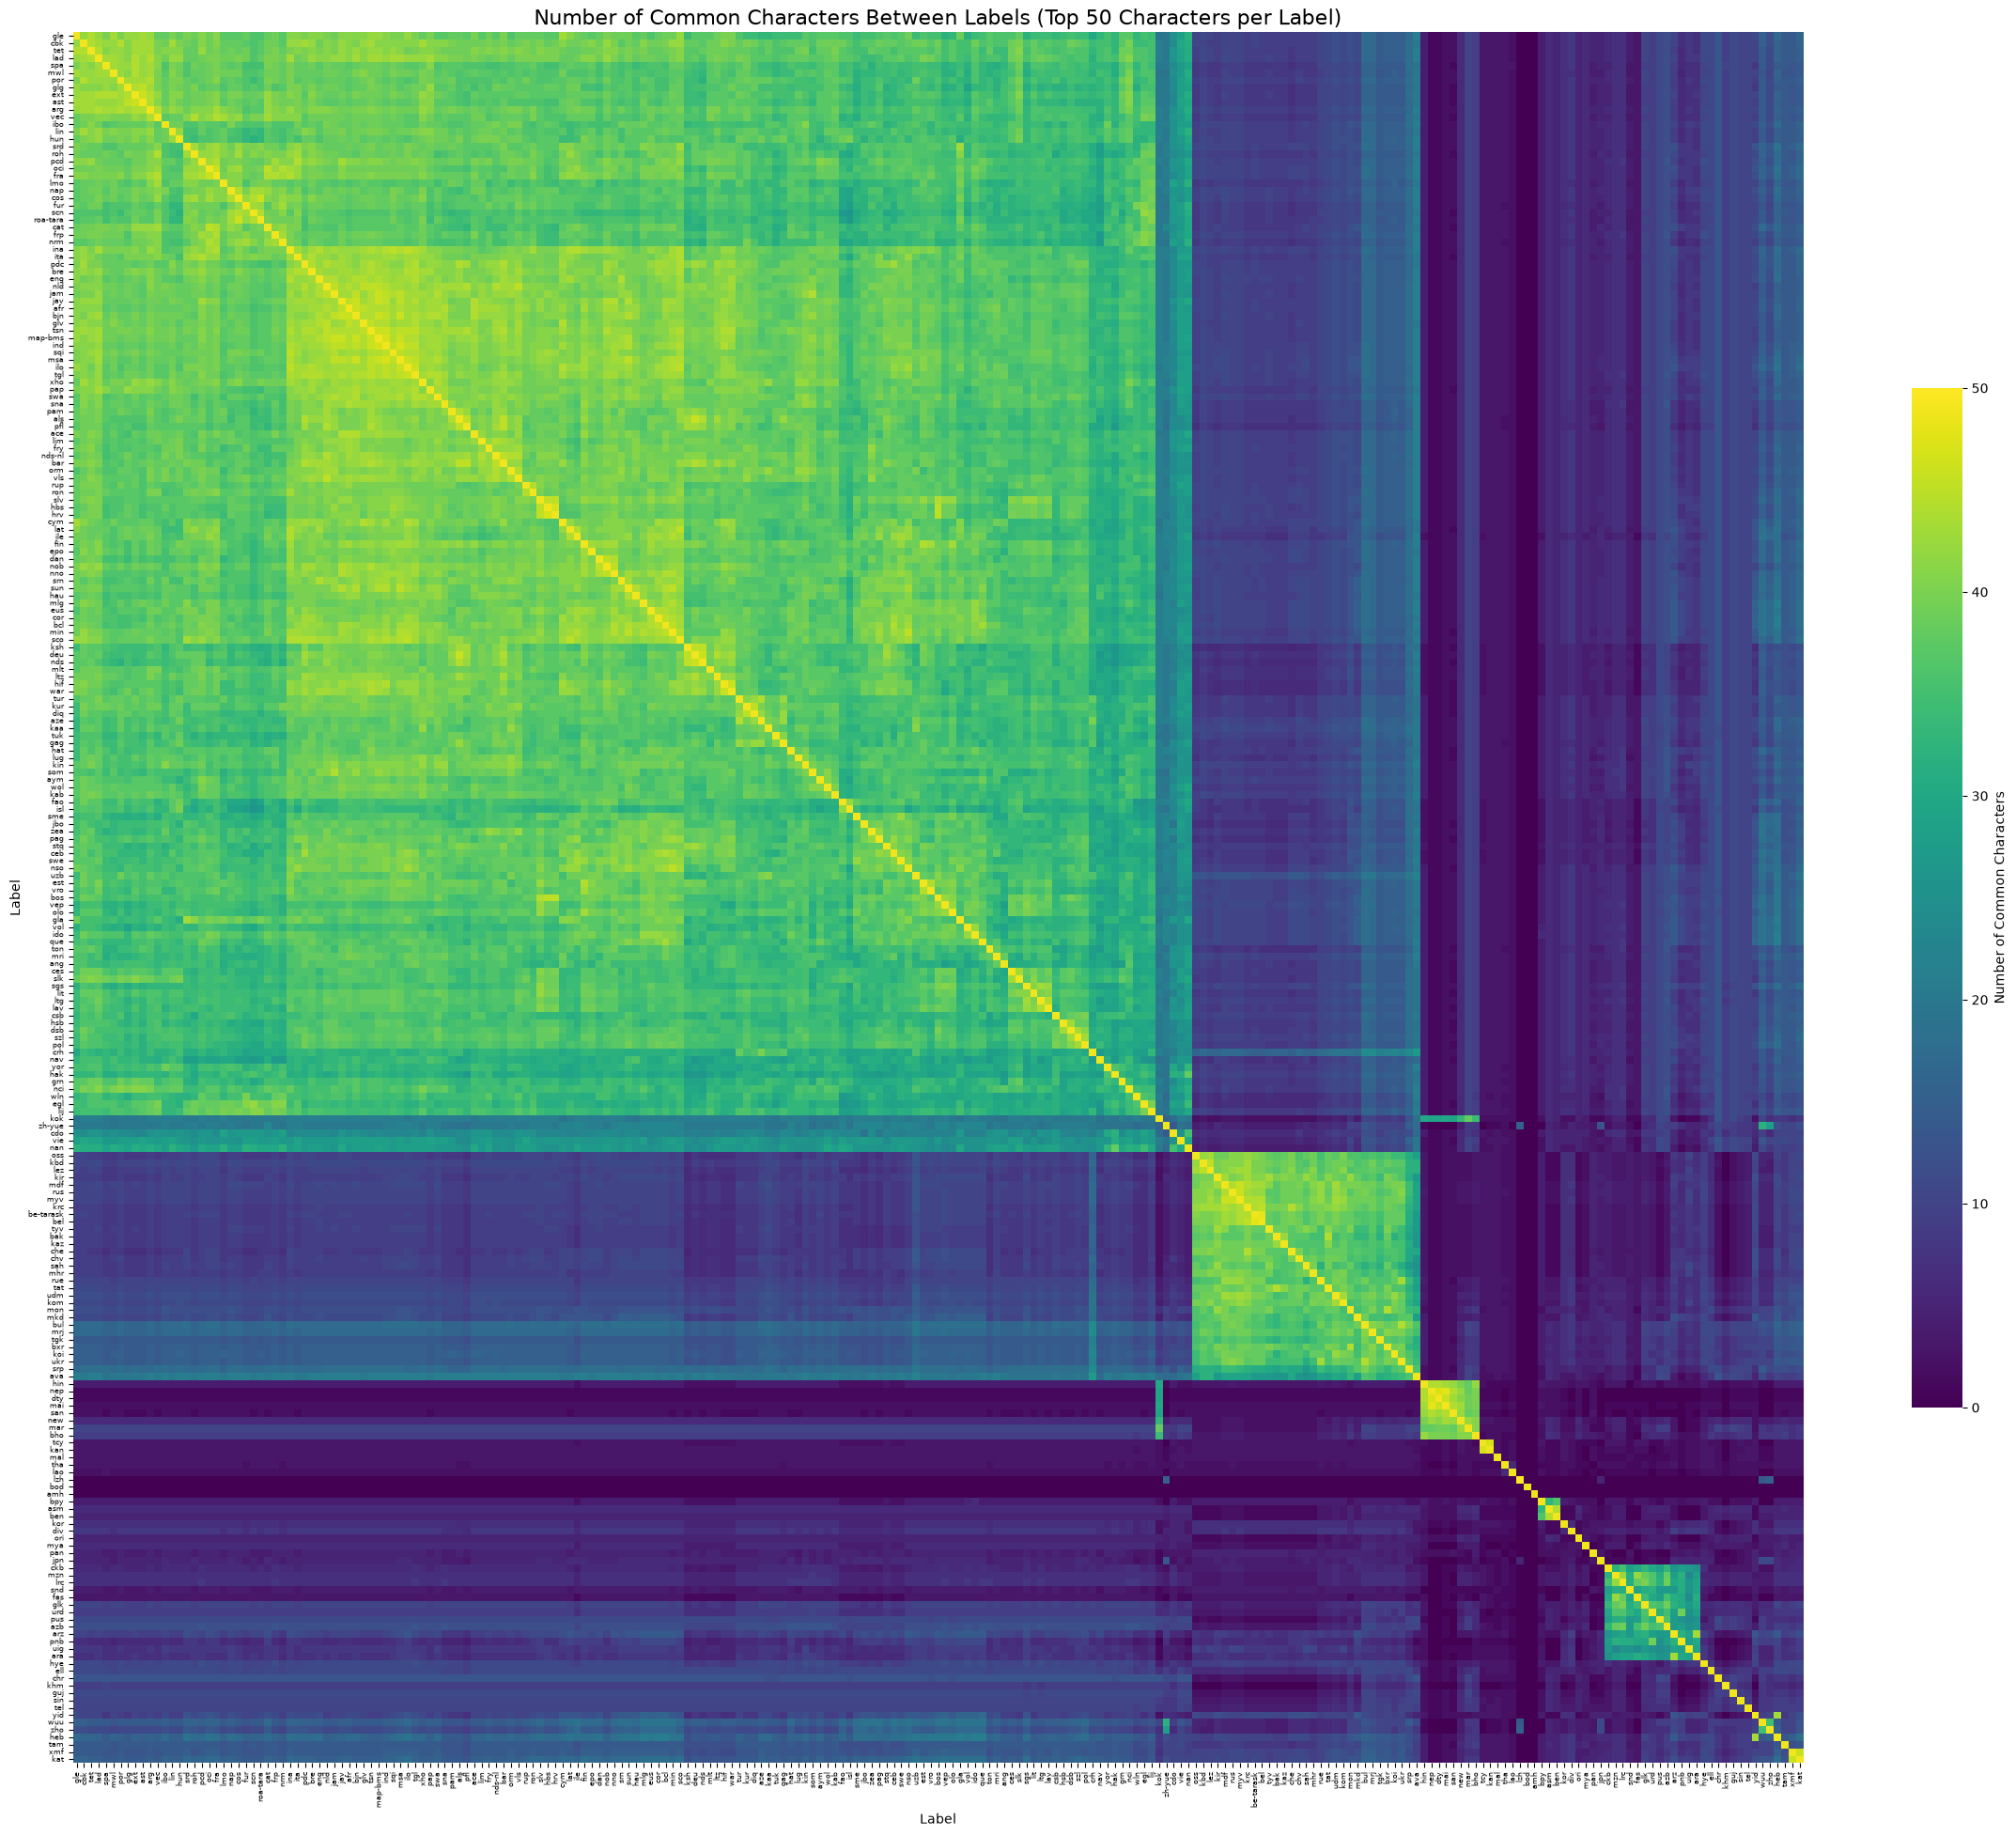

In [21]:
# plot common_chars_matrix as a heatmap
# labels are reordered with hierarchical clustering so that languages sharing many characters (e.g. same script) end up next to each other
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list

matrix = common_chars_matrix.astype(int)
# reorder the matrix using hierarchical clustering using the average linkage method
# first it starts with every language as its own cluster, then it merges the two closest clusters (i.e. languages sharing the most characters) into a new cluster, and repeats this process until all languages are in one cluster
# hierarchical clustering
# 1. col 0, 1	- An index from 0 to 234 is a single language, i.e. that row of matrix. An index of 235 or more is a cluster made in an earlier step
# 2. col 2 - How far apart the two clusters were when they merged. With method='average', this is the average Euclidean distance between their members' rows. Smaller means more similar.
# 3. col 3 - How many languages the new cluster contains.
order = matrix.index[leaves_list(linkage(matrix.values, method='average'))]
matrix = matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(matrix, cmap='viridis', square=True, xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Number of Common Characters', 'shrink': 0.5}, ax=ax)
ax.set_title('Number of Common Characters Between Labels (Top 50 Characters per Label)', fontsize=16)
ax.set_xlabel('Label')
ax.set_ylabel('Label')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

We can group some languages together:
1. Big block, Latin script (150 labels): ace, afr, als, … eng, deu, nld, dan, swe, nob, … The cell prints the full list.
2. Three smaller blocks:
    - Cyrillic (31): ava, bak, be-tarask, bel, bul, bxr, che, chv, kaz, kbd, kir, koi, kom, krc, lez, mdf, mhr, mkd, mon, mrj, myv, oss, rue, rus, sah, srp, tat, tgk, tyv, udm, ukr
    - Arabic script (12): ara, arz, azb, ckb, fas, glk, lrc, mzn, pnb, pus, snd, urd
    - Devanagari (9): bho, dty, hin, kok, mai, mar, nep, new, san
3. Tiny blocks:
    - Chinese: wuu, zh-yue, zho
    - Bengali script: asm, ben, bpy
    - Hebrew script: heb, yid
    - Kannada script: kan, tcy
    - Georgian script: kat, xmf
4. Own characters (21): amh, bod, chr, div, ell, guj, hye, jpn, khm, kor, lao, lzh, mal, mya, ori, pan, sin, tam, tel, tha, uig

In [22]:
# identify the blocks in the heatmap
# two labels are linked if they share at least `threshold` of their top characters,
# and each group is a set of labels connected through such links (connected components of the graph)
from scipy.sparse.csgraph import connected_components

threshold = 30
matrix = common_chars_matrix.astype(int)

# first create adjacency matrix where an edge exists between two labels if they share at least `threshold` characters
adjacency_matrix = (matrix.values >= threshold).astype(int)

# find connected components of the graph if there's a link between two labels
n_groups, group_ids = connected_components(adjacency_matrix, directed=False)
groups = sorted(
    (sorted(matrix.index[group_ids == g]) for g in range(n_groups)),
    key=len, reverse=True,
)

big_block = groups[0]                                       # 1. the big bright block
smaller_blocks = [g for g in groups[1:] if len(g) >= 5]     # 2. the smaller blocks
tiny_blocks = [g for g in groups[1:] if 1 < len(g) < 5]     #    (pairs/triples, barely visible in the heatmap)
own_chars = sorted(g[0] for g in groups if len(g) == 1)     # 3. labels that only share characters with themselves

print(f"1. Big block ({len(big_block)} labels):\n{big_block}\n")
print("2. Smaller blocks:")
for g in smaller_blocks:
    print(f"   ({len(g)} labels) {g}")
print("   Tiny blocks:")
for g in tiny_blocks:
    print(f"   ({len(g)} labels) {g}")
print(f"\n3. Own characters ({len(own_chars)} labels):\n{own_chars}")

1. Big block (150 labels):
['ace', 'afr', 'als', 'ang', 'arg', 'ast', 'aym', 'aze', 'bar', 'bcl', 'bjn', 'bos', 'bre', 'cat', 'cbk', 'cdo', 'ceb', 'ces', 'cor', 'cos', 'crh', 'csb', 'cym', 'dan', 'deu', 'diq', 'dsb', 'egl', 'eng', 'epo', 'est', 'eus', 'ext', 'fao', 'fin', 'fra', 'frp', 'fry', 'fur', 'gag', 'gla', 'gle', 'glg', 'glv', 'grn', 'hak', 'hat', 'hau', 'hbs', 'hif', 'hrv', 'hsb', 'hun', 'ibo', 'ido', 'ile', 'ilo', 'ina', 'ind', 'isl', 'ita', 'jam', 'jav', 'jbo', 'kaa', 'kab', 'kin', 'ksh', 'kur', 'lad', 'lat', 'lav', 'lij', 'lim', 'lin', 'lit', 'lmo', 'ltg', 'ltz', 'lug', 'map-bms', 'min', 'mlg', 'mlt', 'mri', 'msa', 'mwl', 'nan', 'nap', 'nav', 'nci', 'nds', 'nds-nl', 'nld', 'nno', 'nob', 'nrm', 'nso', 'oci', 'olo', 'orm', 'pag', 'pam', 'pap', 'pcd', 'pdc', 'pfl', 'pol', 'por', 'que', 'roa-tara', 'roh', 'ron', 'rup', 'scn', 'sco', 'sgs', 'slk', 'slv', 'sme', 'sna', 'som', 'spa', 'sqi', 'srd', 'srn', 'stq', 'sun', 'swa', 'swe', 'szl', 'tet', 'tgl', 'ton', 'tsn', 'tuk', 'tur', '

some languages are very similar based on ngram

In [23]:
# closely related languages: compare character trigram profiles of every pair of labels
# each label becomes one vector of trigram frequencies (all its training texts joined together),
# and cosine similarity close to 1 means the two labels use almost the same trigrams in the same proportions
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

label_texts = train_df.groupby('label')['text'].apply(' '.join)
trigram_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), use_idf=False, max_features=200_000)
trigram_profiles = trigram_vectorizer.fit_transform(label_texts)
trigram_similarity = pd.DataFrame(cosine_similarity(trigram_profiles), index=label_texts.index, columns=label_texts.index)

# keep each pair once (upper triangle without the diagonal) and list the most similar pairs
upper = np.triu(np.ones(trigram_similarity.shape, dtype=bool), k=1)
similar_pairs = (
    trigram_similarity.where(upper).stack()
    .rename_axis(['label1', 'label2']).reset_index(name='cosine_similarity')
    .sort_values('cosine_similarity', ascending=False)
)
similar_pairs.head(20)

,label1,label2,cosine_similarity
17232,hbs,hrv,0.981783
20347,ind,msa,0.980292
5478,bos,hbs,0.976227
5482,bos,hrv,0.976006
4013,be-tarask,bel,0.937533
10022,dan,nob,0.924226
7005,cbk,spa,0.919270
2305,ast,spa,0.916766
15444,glg,por,0.916688
20336,ind,map-bms,0.915780


Some languages have bad examples - the same text have different labels

In [24]:
# same text under different labels: texts that appear more than once with conflicting labels
full_df = pd.concat([train_df.assign(split='train'), test_df.assign(split='test')])
labels_per_text = full_df.groupby('text')['label'].unique()
conflicting = labels_per_text[labels_per_text.str.len() > 1]

print(f"{len(conflicting)} distinct texts appear with more than one label "
      f"({full_df['text'].isin(conflicting.index).sum()} rows in train + test)\n")

# which label combinations conflict most often
conflict_pairs = conflicting.apply(lambda l: ' / '.join(sorted(l))).value_counts()
print(conflict_pairs.head(10).to_string(), '\n')

# a few examples
pd.DataFrame({'labels': conflicting.apply(sorted), 'text': conflicting.index.str[:100]}).reset_index(drop=True).head(5)

130 distinct texts appear with more than one label (524 rows in train + test)

label
ava / pcd        82
dty / nep        13
ava / lez         8
ace / map-bms     3
lrc / snd         2
pdc / pfl         2
kan / mai         2
dsb / hsb         2
ina / srd         2
hau / wol         1 



,labels,text
0,"[hau, wol]","""Esperanto""; FUNDAMENTO DE ESPERANTO Antaŭparo..."
1,"[lrc, snd]",'باسكن روبنز هو كريم كريم المؤسسة الأمريكية ال...
2,"[ava, pcd]",(Apologies if this message isn't in your langu...
3,"[ava, pcd]",(Apologies if this message isn't in your langu...
4,"[ava, pcd]",(Apologies if this message isn't in your langu...


Some languages have overlapping train and test examples

In [25]:
# overlap between train and test: exact duplicate texts within each split and across the two splits
train_texts = set(train_df['text'])
test_in_train = test_df['text'].isin(train_texts)

print(f"Duplicate rows within train: {train_df['text'].duplicated().sum()}")
print(f"Duplicate rows within test:  {test_df['text'].duplicated().sum()}")
print(f"Test rows whose text also appears in train: {test_in_train.sum()} of {len(test_df)} "
      f"({test_in_train.mean():.1%})\n")

# per label: how many of the 500 test examples were already seen in training
overlap_per_label = (
    test_df.assign(in_train=test_in_train)
    .groupby('label')['in_train'].agg(overlapping='sum', share='mean')
    .sort_values('overlapping', ascending=False)
)
overlap_per_label[overlap_per_label['overlapping'] > 0].head(15)

Duplicate rows within train: 2681
Duplicate rows within test:  2720
Test rows whose text also appears in train: 3147 of 117500 (2.7%)



,overlapping,share
label,,
che,449,0.898
hat,407,0.814
new,324,0.648
pam,290,0.580
min,160,0.320
srn,136,0.272
hsb,121,0.242
sun,112,0.224
bak,100,0.200


### 1.2 Data preparation

Get a subset of the train/test data that includes 20 languages.
Include English (`eng`), German (`deu`), Dutch (`nld`), Danish (`dan`), Swedish (`swe`), Norwegian (either Bokmål `nob` or Nynorsk `nno`), and Japanese (`jpn`), plus 13 additional languages of your choice based on the items in the list of labels.

Note that `sklearn` classifiers accept string labels such as `'eng'` directly; the order of the classes is stored in `clf.classes_` after fitting.

In [26]:
# TODO: Create your train/test subsets of languages
selected_labels = sorted(['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn'])
additional_labels = sorted(['fra', 'spa', 'ita', 'rus', 'ara', 'hin', 'zho', 'asm', 'heb', 'kan', 'kor', 'tha', 'vie'])
all_labels = sorted(selected_labels + additional_labels)

from sklearn.model_selection import train_test_split
# shuffle the train_df and test_df to ensure randomness and use 80% of the data for training and 20% for testing
train_test_df = pd.concat([train_df, test_df]).sample(frac=1, random_state=42).reset_index(drop=True)
train_test_df = train_test_df[train_test_df['label'].isin(all_labels)].drop_duplicates(subset=['text'])
x_train, x_test, y_train, y_test = train_test_split(
    train_test_df['text'], train_test_df['label'],
    test_size=0.2, stratify=train_test_df['label'], random_state=42)

print('num x_train:', len(x_train))
print('num x_test:', len(x_test))

num x_train: 15984
num x_test: 3996


In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(y_train)
y_train, y_test = label_encoder.transform(y_train), label_encoder.transform(y_test)
print(label_encoder.classes_)
print(y_train)
print(y_test)

['ara' 'asm' 'dan' 'deu' 'eng' 'fra' 'heb' 'hin' 'ita' 'jpn' 'kan' 'kor'
 'nld' 'nob' 'rus' 'spa' 'swe' 'tha' 'vie' 'zho']
[2 2 5 ... 6 9 2]
[19 12 11 ...  8 18 14]


### 2.1 Build a LogisticRegression classifier

To start with, we're going to build a very simple LogisticRegression classifier.
Use a `Pipeline` to chain togther a `CountVectorizer` and a `LogisticRegression` estimator. Then perform a 5-fold cross validation and report the scores of this model as a baseline.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# TODO: Define a very basic pipeline using a CountVectorizer and a LogisticRegression classifier
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()), # word-level tokenization with default settings
    ('classifier', LogisticRegression())
])

In [29]:
# TODO: Run a cross validation to estimate the model's expected performance
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV accuracy: {cv_scores.mean():.4f}, std: {cv_scores.std()}")

Mean CV accuracy: 0.9436, std: 0.004601406288006003


### 2.2 Feature Engineering

So far, we've only considered the basic `CountVectorizer` at the word level to encode our input texts for our model.

Your task is to apply some text preprocessing and engineer some more informative features.

To do this, think about what other features might be relevant for determining the language of an input text.

Define a custom set of feature extractors and implement the necessary preprocessing steps to extract these features from strings.

Then initialise a processing pipeline that converts your input data into features that the model can take as input.

☝ Note, this step can be as involved as your heart desires, there is only one minimal requirement: you must use something more than the base `CountVectorizer`, and your features must be different from the document statistics shown in the W03 tutorial.


In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler

def report(name, pipeline):
    scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

In [31]:
pipeline_char = Pipeline([
    ('vect', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, max_features=100_000)),
    ('reg', LogisticRegression()),
])
report('char_wb (2,3), min_df=0.5%, tf-idf', pipeline_char)

char_wb (2,3), min_df=0.5%, tf-idf: 0.9859 ± 0.0019


In [32]:
pipeline_word_char = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, max_features=50_000)),
    ])),
    ('reg', LogisticRegression()),
])
report('word + char_wb', pipeline_word_char)

word + char_wb: 0.9872 ± 0.0016


In [33]:
import re

def clean_text(text):
    text = re.sub(r'https?://\S+', ' ', text)   # URLs
    text = re.sub(r'\d+', ' ', text)            # numbers
    return re.sub(r'\s+', ' ', text).strip()    # collapse whitespace

pipeline_clean = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
    ])),
    ('reg', LogisticRegression()),
])
report('cleaned char_wb', pipeline_clean)

cleaned char_wb: 0.9879 ± 0.0014


In [34]:
import unicodedata
from sklearn.base import BaseEstimator, TransformerMixin

class TextStats(BaseEstimator, TransformerMixin):
    """Hand-crafted statistics about how a text is written."""
    feature_names = ['avg_word_len', 'space_ratio', 'upper_ratio', 'digit_ratio', 'punct_ratio', 'non_ascii_ratio']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rows = []
        for text in X:
            n = max(len(text), 1)
            words = text.split()
            rows.append([
                np.mean([len(w) for w in words]) if words else 0,
                text.count(' ') / n,
                sum(c.isupper() for c in text) / n,
                sum(c.isdigit() for c in text) / n,
                sum(unicodedata.category(c).startswith('P') for c in text) / n,
                sum(ord(c) > 127 for c in text) / n,
            ])
        return np.array(rows)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names)

In [36]:
pipeline_full = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('stats', Pipeline([('extract', TextStats()), ('scale', StandardScaler())])),
    ])),
    ('reg', LogisticRegression()),
])
report('char_wb + stats', pipeline_full)

char_wb + stats: 0.9868 ± 0.0013


In [37]:
# examples the model gets wrong, using 5-fold cross-validated predictions on the training set
# (each text is predicted by a model that did not see it during training, so the test set stays untouched)
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(pipeline_full, x_train, y_train, cv=5)
errors = pd.DataFrame({
    'true': label_encoder.inverse_transform(y_train),
    'predicted': label_encoder.inverse_transform(y_pred),
    'text': x_train.to_numpy(),
})
errors = errors[errors['true'] != errors['predicted']]
print(f"{len(errors)} of {len(x_train)} training texts misclassified ({len(errors) / len(x_train):.1%})\n")

# which confusions happen most often
print(errors.groupby(['true', 'predicted']).size().sort_values(ascending=False).head(10).to_string(), '\n')

# a few examples (text truncated to 200 characters)
with pd.option_context('display.max_colwidth', 200):
    display(errors.sample(10, random_state=42).assign(text=lambda d: d['text'].str[:200]))

211 of 15984 training texts misclassified (1.3%)

true  predicted
asm   eng          25
hin   eng          12
dan   deu          11
      nob           8
nob   eng           8
tha   eng           8
vie   eng           7
nob   dan           7
zho   eng           7
kor   zho           6 



,true,predicted,text
1780,dan,nob,"Lipetsk oblast grænser i nordøst til Rjasan oblast, Tambov oblast i øst, Voronezj oblast i syd, Kursk oblast i sydvest, Orjol oblast i vest og Tula oblast i nordvest."
12999,hin,eng,"""The definitions are not authentic as the Rubber which is classified in World Customs Organisation Books in Chapter 40, where as the above definitions stating all rubber and different polymers in ..."
10617,hin,eng,"In 1947, the U.S. established a central intelligence agency to coordinate its various foreign intelligence efforts. It was named the Central Intelligence Agency."
5103,dan,eng,"(engelsk: That the enemy may withdraw his land-based air forces to the Asiatic Mainland for protection from our neutralizing attacks. That under such circumstances he can possibly amass from 2,000..."
3849,kan,vie,"Tamil Nadu State Film Award for Best Actress |- | Manmadhan | Mythili | Tamil |- | Mass | Anjali | Telugu |- | rowspan=""2"" | 2005 | Maayavi | Actress Jothika (Jo) | Tamil |- | Chandramukhi | Ganga..."
15608,vie,eng,"Sau trận này, Noori đấu trận One Day International đầu tiên với Canada ở sân Sharjah Cricket Association Stadium. Noori chỉ ghi được 9 runs from number six. He was later named in Afghanistan's squ..."
2724,jpn,rus,"Дьяконов М. А., Кивлицкий Е. А.,Русская Правда, памятник древнерусского права // Энциклопедический словарь Брокгауза и Ефрона（ブロックハウス・エフロン百科事典）— СПб., 1890—1907."
13406,rus,eng,"Hilts, PJ. Scientist at Work: Mark Ptashne; Virtuoso in Plucking Violin or Secrets of Genetic Switches, The New York Times (24 February 1998). Проверено 28 сентября 2009."
656,dan,deu,"Alvise da Mosto, L'ARCHIVIO DI STATO DI VENEZIA. INDICE GENERALE, STORICO, DESCRITTIVO ED ANALITICO (PDF, 796 kB eller i HTML-Format) – overbliksværk over samlingerne i statsarkivet i Venedig, og ..."
7157,jpn,zho,"この記事にはアメリカ合衆国内で著作権が消滅した次の百科事典本文を含む: Chisholm, Hugh, ed. (1911). ""La Rochejacquelein, De"". Encyclopædia Britannica. 16 (11th ed.). Cambridge University Press."


there are for sure many examples that are labeled wrongly
- This is not 'kor' 彼以聞慧。觀諸畜生種類差別。三十四億。隨心自在。生於五道。於五道中。畜生種類。其數最多。種種相貌。種種色類。行食不同。群飛各異。憎愛違順。伴行雙隻。同生共遊。所謂飛禽。及諸走獸。烏鵲鵝鴈。鴻鳥眾類。異群別遊。不相怨害。狐狗野干等。互相憎嫉。烏與角鴟。馬及水牛。蚖蛇鼬等。共相殘害。形相不同。行食各異。以何業故。種種形相行食各異。彼以聞慧。觀是眾生。爲種種心之所役使。作種種業。入種種道。噉種種食。
- This is not 'tha' Titsingh, I. (1822). Illustrations of Japan; consisting of Private Memoirs and Anecdotes of the reigning dynasty of The Djogouns, or Sovereigns of Japan. London: Ackerman.

In [38]:
train_test_df[train_test_df['label'] == 'kor'].head(10)

,text,label
133,그는 그의 오페라의 공연을 위해 특별히 건축된 오페라 하우스인 바이로이트 축제극장에...,kor
197,"1906년 8월 궁내부 주사, 1907년 궁내부 서기랑을 역임했으며 1911년 2월...",kor
386,필사본 《화랑세기》에서는 12대 풍월주 보리공(菩利公)의 딸 보룡(寶龍)과의 사이에...,kor
1139,오랜 세월이 흐르고 그는 아웃랜드의 황제 자리에 올랐다. 그러나 결국 아웃랜드를 제...,kor
1180,현재의 쿠알라룸푸르에 해당하는 슬랑오르 주의 스타팍에서 다하리 아벵과 아미나 빈티 ...,kor
1804,1954년 11월 자유당이 이승만의 3선을 확정하기 위해 분주히 움직일 때 이기붕은...,kor
1899,彼以聞慧。觀諸畜生種類差別。三十四億。隨心自在。生於五道。於五道中。畜生種類。其數最多。種種...,kor
2115,"덧붙여 그롬의 무기는 ""피의 울음소리""이라는 도끼로 그가 사망하고 나서는 스랄이 보...",kor
2353,"좌파 민족주의는 국가의 평등과 자주적 자유를 옹호하면서, 노동자 및 농민 세력의 해...",kor
2355,"민원식은 ""매춘부는 도덕상에 해물(害物)인데 사회위생상 필요물""이라는 관점에서 매춘...",kor


---

### 3.1 Grid Search

Use sklearn's GridSearchCV and experiment with the following hyperparameters:
1. Regularization: its strength `C` and its type via `l1_ratio` (`l1_ratio=0` is L2, `l1_ratio=1` is L1)
2. Solver (note that not every solver supports every regularization type)
3. Experiment with parameters of the Vectorizer (optional, but highly advised)

☝ Note, don't overdo it at the beginning, since runtime might go up fast!

Make sure you read through the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to get an understanding of what these parameters do.

In [39]:
from sklearn.model_selection import GridSearchCV

vect_grid = {
    'vect__char__ngram_range': [(2, 3), (2, 4), (1, 5)],   # longer n-grams catch short words: 'och', 'und', 'het'
    'vect__char__max_features': [50_000, 200_000],          # does the 50k cap hurt?
    'vect__char__lowercase': [True, False],                # capitals matter for German nouns
}

vect_search = GridSearchCV(pipeline_clean, vect_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
vect_search.fit(x_train, y_train)
print(vect_search.best_params_, f"{vect_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'vect__char__lowercase': True, 'vect__char__max_features': 200000, 'vect__char__ngram_range': (1, 5)} 0.9879


In [40]:
results = pd.DataFrame(vect_search.cv_results_)
fold_cols = [c for c in results.columns if c.startswith('split') and c.endswith('_test_score')]

(results[['params', *fold_cols, 'mean_test_score', 'std_test_score', 'mean_fit_time', 'rank_test_score']]
 .sort_values('rank_test_score'))

,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,mean_fit_time,rank_test_score
5,"{'vect__char__lowercase': True, 'vect__char__m...",0.986674,0.988551,0.988363,0.987863,0.000844,252.006577,1
11,"{'vect__char__lowercase': False, 'vect__char__...",0.986674,0.988551,0.988363,0.987863,0.000844,160.035958,1
6,"{'vect__char__lowercase': False, 'vect__char__...",0.986674,0.988739,0.987800,0.987738,0.000844,113.949341,3
0,"{'vect__char__lowercase': True, 'vect__char__m...",0.986674,0.988739,0.987800,0.987738,0.000844,114.568094,3
9,"{'vect__char__lowercase': False, 'vect__char__...",0.986486,0.988551,0.987988,0.987675,0.000871,163.403707,5
3,"{'vect__char__lowercase': True, 'vect__char__m...",0.986486,0.988551,0.987988,0.987675,0.000871,178.577720,5
2,"{'vect__char__lowercase': True, 'vect__char__m...",0.986111,0.988551,0.987988,0.987550,0.001043,178.449881,7
8,"{'vect__char__lowercase': False, 'vect__char__...",0.986111,0.988551,0.987988,0.987550,0.001043,169.093966,7
1,"{'vect__char__lowercase': True, 'vect__char__m...",0.986111,0.988551,0.987425,0.987362,0.000997,154.921327,9
7,"{'vect__char__lowercase': False, 'vect__char__...",0.986111,0.988551,0.987425,0.987362,0.000997,151.315405,9


In [41]:
# lowercase or not doesn't change the result
results.loc[11]

mean_fit_time                                                            160.035958
std_fit_time                                                              18.204126
mean_score_time                                                            6.181756
std_score_time                                                             0.886024
param_vect__char__lowercase                                                   False
param_vect__char__max_features                                               200000
param_vect__char__ngram_range                                                (1, 5)
params                            {'vect__char__lowercase': False, 'vect__char__...
split0_test_score                                                          0.986674
split1_test_score                                                          0.988551
split2_test_score                                                          0.988363
mean_test_score                                                            0

In [42]:
results.loc[0]

mean_fit_time                                                            114.568094
std_fit_time                                                               7.037725
mean_score_time                                                           11.565636
std_score_time                                                             0.288268
param_vect__char__lowercase                                                    True
param_vect__char__max_features                                                50000
param_vect__char__ngram_range                                                (2, 3)
params                            {'vect__char__lowercase': True, 'vect__char__m...
split0_test_score                                                          0.986674
split1_test_score                                                          0.988739
split2_test_score                                                            0.9878
mean_test_score                                                            0

In [43]:
from sklearn.base import clone
chosen_params = results.iloc[0]['params']       
best_pipeline = clone(pipeline_clean).set_params(**chosen_params)

model_grid = [
    # L2 (ridge): shrinks all weights a little; the default
    {'reg__l1_ratio': [0], 'reg__solver': ['lbfgs', 'saga', 'newton-cg'], 'reg__C': [0.1, 1, 10, 100]},
    # L1 (lasso): sets most weights to exactly 0, so you get a small set of useful n-grams
    {'reg__l1_ratio': [1], 'reg__solver': ['saga'], 'reg__C': [1, 10, 100]},
]
best_pipeline.set_params(reg__max_iter=1000)

model_search = GridSearchCV(best_pipeline, model_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=3)
model_search.fit(x_train, y_train)
print(model_search.best_params_, f"{model_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'reg__C': 100, 'reg__l1_ratio': 0, 'reg__solver': 'newton-cg'} 0.9897


### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the using the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` returns a dictionay, so convert it to a Pandas Dataframe for easy inspection.)

📝❓ What were the hyperparameter combinations for your best-performing model on the test set.

📝❓ What is the advantage of grid search cross-validation?


In [44]:
# TODO: Select the best model based on the GridSearch results
print(model_search.best_params_, f"{model_search.best_score_:.4f}")

{'reg__C': 100, 'reg__l1_ratio': 0, 'reg__solver': 'newton-cg'} 0.9897


Best hyperparameter combination
- char__max_features = 200000
- char__ngram_range = (1, 5)
- reg__C = 100
- reg__penalty = l1
- reg__solver = newton-cg

Advantages of grid search cross-validation
- Grid search evaluates every combination of the given hyperparameter values. the best combination is then retrained on the full training set.
- With k-fold cross-validation, it gives a more reliable score than a single validation split (with mean and std), and every training example is used for validation once. It also ensures that hyperparameters are selected using only the training data, so the final test score remains an unbiased estimate of performance on unseen data.

## 3.3 Model Evaluation

Once you have identified your best model, use it to predict the languages of texts in the test split.

📝❓ According to standard metrics (e.g. Accurracy, Precision, Recall and F1), how well does your model perform on the heldout test set?


In [45]:
# TODO: Evaluate the model by inspecting the predictions on the heldout test set
# final model = best hyperparameters from the grid search, refit on the full training set (refit=True)
# note: with 20 classes there is no 0.5 threshold; predict() picks the class with the highest probability (argmax)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

final_model = model_search.best_estimator_
y_pred = final_model.predict(x_test)

# overall metrics: macro = unweighted mean over the 20 languages
# (micro-averaged precision/recall/F1 are identical to accuracy for single-label multiclass, so not shown)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro precision: {precision:.4f}")
print(f"Macro recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}\n")

# per-language metrics
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

# confusion matrix: rows = true language, columns = predicted language
cm = confusion_matrix(y_test, y_pred)

# the off-diagonal cells are hard to read with 20 classes, so also list the most frequent confusions
confusions = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
confusions = confusions.where(~np.eye(len(confusions), dtype=bool)).stack()
confusions = confusions[confusions > 0].astype(int).sort_values(ascending=False)
confusions.rename_axis(['true', 'predicted']).rename('count').head(10)

Accuracy:        0.9900
Macro precision: 0.9908
Macro recall:    0.9900
Macro F1:        0.9902

              precision    recall  f1-score   support

         ara     1.0000    1.0000    1.0000       200
         asm     0.9949    0.9700    0.9823       200
         dan     1.0000    0.9750    0.9873       200
         deu     0.9900    0.9950    0.9925       200
         eng     0.8800    0.9900    0.9318       200
         fra     0.9899    0.9899    0.9899       198
         heb     1.0000    0.9950    0.9975       200
         hin     1.0000    0.9750    0.9873       200
         ita     0.9804    1.0000    0.9901       200
         jpn     1.0000    0.9900    0.9950       200
         kan     1.0000    1.0000    1.0000       200
         kor     1.0000    0.9950    0.9975       200
         nld     1.0000    0.9900    0.9950       200
         nob     0.9950    0.9950    0.9950       200
         rus     1.0000    0.9800    0.9899       200
         spa     0.9949    0.9899    0

true  predicted
asm   eng          6
hin   eng          5
dan   eng          3
rus   eng          3
fra   eng          2
tha   eng          2
deu   fra          1
dan   ita          1
      deu          1
heb   eng          1
Name: count, dtype: int64

---

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

📝❓ Where does your model do well and where does it fail?

📝❓ What are some possible reasons for why it fails in these cases?

Where model do well, and where does it fail:
- do well: when the texts are not dominated with other languages
- do poorly: when label seems to be wrong, mostly predicted as eng because the text is actually in english but was probably scraped from a page in a specific language.

In [46]:
# TODO: Inspect the model's predcitions on the different classes
# print test examples for the most frequent (true, predicted) confusions from the cell above,
# next to correctly classified examples of both languages for comparison
n_pairs = 5               # how many of the most frequent confusions to show
n_examples_per_pair = 3   # how many misclassified texts to print for each confusion
n_correct_examples = 2    # how many correctly classified texts to print for each of the two languages
max_chars = 300           # truncate long texts

test_results = pd.DataFrame({
    'true': label_encoder.inverse_transform(y_test),
    'predicted': label_encoder.inverse_transform(y_pred),
    'text': x_test.to_numpy(),
})
correct = test_results[test_results['true'] == test_results['predicted']]

def print_texts(texts):
    for text in texts:
        print(f"- {text[:max_chars]}{'...' if len(text) > max_chars else ''}\n")

for (true_label, predicted_label), count in confusions.head(n_pairs).items():
    examples = test_results[(test_results['true'] == true_label) & (test_results['predicted'] == predicted_label)]
    print(f"===== true={true_label}, predicted={predicted_label} ({count} texts) =====")
    print_texts(examples['text'].head(n_examples_per_pair))
    for label in [true_label, predicted_label]:
        print(f"  --- correctly classified {label} ---")
        print_texts(correct.loc[correct['true'] == label, 'text'].sample(n_correct_examples, random_state=42))
    print()

===== true=asm, predicted=eng (6 texts) =====
- Tailorbirds are found in singly or in pairs, usually low in the undergrowth or trees sometimes hopping on the ground. They forage for insects and have been known to feed on a range of beetles and bugs. They are attracted to insects at flowers and are known to favour the inflorescenses of mango. They...

- The final session of parliament started on 6 February and ended on 21 February. Amongst the agenda in the final session is passing the The Lokpal and Lokayuktas Bill, 2013 in tackling corruption and the creation of Telangana.

- Sefi, A.J. An Introduction to Advanced Philately, with special reference to typical methods of stamp production. London: Rowley & Rowley, 1926. (2nd edition 1932) (Electronic facsimile edition Royal Philatelic Society London 2010.)

  --- correctly classified asm ---
- চক্ৰৱৰ্তী ৰাজাগোপালাচাৰীৰ জন্ম হয় ১৮৭৯ চনত মাদ্ৰাছ প্ৰেছিডেন্সীৰ অন্তৰ্গত তামিলনাডুৰ থোৰাপল্লী গাঁৱত। পিতাক আছিল মুন্সিফ। ৰাজাজী সৰুৰে পৰা পঢ়াত 

---

### 5.1 Interpretability Analysis

Now that you have your best model, it's time to dive deep into understanding how the model makes predictions.

It is important that we can explain and visualise our models to improve task performance. Explainable models help characterise model fairness, transparency, and outcomes.

Let's try to understand what our best-performing logistic regression classification model has learned.

Inspect the 20 most important features for the languages English, Swedish, Norwegian (whichever of `nob`/`nno` you included), and Japanese. Please make sure that the features are named and human-interpretable, not things like "Feat_1". (Hint: if you have used custom feature extractors in your pipeline, you may need to adapt these to make sure that the feature names are maintained.)

📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

We recommend using the [SHAP library](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/linear_models/Sentiment%20Analysis%20with%20Logistic%20Regression.html) as discussed in the [W03 tutorial](https://github.com/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/tutorials_notebooks_in_class_2026/W03_pipeline_gridsearch_shap.ipynb), which shows SHAP for a multi-class linear model.

☝ Note, if you prefer to use another interpretability tool, we will accept answers from any explanation library/method as long as the explanations for the model weights are provided in a structured/clear way.



What's more important
- by using SHAP, we can see that the extra features are more important, which makes sense since if the extra features can shift the prediction a lot. For example, by seeing that a text has so many space, it has ruled out so many languages already.
- however, the features from the vectorizer are better predictors when combined (but are not good alone)

In [ ]:
# To use shap, we first need to install it into the current environment
!pip install --upgrade shap

import shap

In [47]:
# TODO: Inspect most important features according to the model using SHAP

# our best model (model_search.best_estimator_) only uses vectorizer features (word + char n-grams).
# to answer "extra features vs vectorizer", we add the hand-crafted TextStats features to the same configuration
# (same vectorizer settings, same C / penalty / solver) and refit it on the full training set
import warnings
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

interp_model = clone(final_model)
interp_model.named_steps['vect'].transformer_list.append(
    ('stats', Pipeline([('extract', TextStats()), ('scale', StandardScaler())]))
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)   # 'penalty' deprecation warning from scikit-learn 1.8+
    # same 3 folds as the grid search (StratifiedKFold without shuffling), so the scores are comparable
    interp_cv = cross_val_score(interp_model, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    interp_model.fit(x_train, y_train)

print(f"best model (vectorizer only):      CV accuracy {model_search.best_score_:.4f}")
print(f"best model + TextStats features:   CV accuracy {interp_cv.mean():.4f} ± {interp_cv.std():.4f}")

best model (vectorizer only):      CV accuracy 0.9897
best model + TextStats features:   CV accuracy 0.9892 ± 0.0004


We can look at the mean SHAP and SHAP swarm plot on each language

In [48]:
# for a linear model with independent features, SHAP has an exact closed form (this is what shap.LinearExplainer computes):
#     shap_value[text i, feature j, class k] = w_kj * (x_ij - mean_j)
# i.e. how much feature j moves the score (logit) of class k for this text, compared with an average training text.
# unlike raw weights, this accounts for the scale of each feature (tf-idf values are small, scaled TextStats values are ~1),
# so word n-grams, char n-grams and the extra features can be compared fairly.
#
# a dense (texts x ~100k features x 20 classes) SHAP array would need tens of GB, so we first compute the
# mean |SHAP| per feature directly on the sparse matrix, and only build shap Explanations for the top features
from scipy import sparse

vectorizer = interp_model.named_steps['vect']
classifier = interp_model.named_steps['reg']

# human-readable feature names, e.g. 'word__the', 'char__ th', 'stats__avg_word_len' (spaces shown as '␣')
feature_names = np.array([name.replace(' ', '␣') for name in vectorizer.get_feature_names_out()])
feature_block = np.array([name.split('__')[0] for name in vectorizer.get_feature_names_out()])

X_train_features = sparse.csc_matrix(vectorizer.transform(x_train))
X_test_features = sparse.csc_matrix(vectorizer.transform(x_test))
feature_means = np.asarray(X_train_features.mean(axis=0)).ravel()   # the SHAP baseline: an average training text

def mean_abs_deviation(X, means):
    """mean over texts of |x_ij - mean_j| for every feature j, computed without densifying the sparse matrix X"""
    n_texts = X.shape[0]
    n_nonzero = np.diff(X.indptr)                                    # per column (X is CSC)
    column_of_value = np.repeat(np.arange(X.shape[1]), n_nonzero)
    nonzero_part = np.bincount(column_of_value, weights=np.abs(X.data - means[column_of_value]), minlength=X.shape[1])
    zero_part = (n_texts - n_nonzero) * np.abs(means)              # texts where the feature is 0
    return (nonzero_part + zero_part) / n_texts

# mean |SHAP| over all test texts, per class and feature: |w_kj| * mean_i |x_ij - mean_j|
deviation = mean_abs_deviation(X_test_features, feature_means)
mean_abs_shap = pd.DataFrame(np.abs(classifier.coef_) * deviation,
                             index=label_encoder.classes_, columns=feature_names)
print(f"{len(feature_names)} features:", pd.Series(feature_block).value_counts().to_dict())

100006 features: {'word': 50000, 'char': 50000, 'stats': 6}


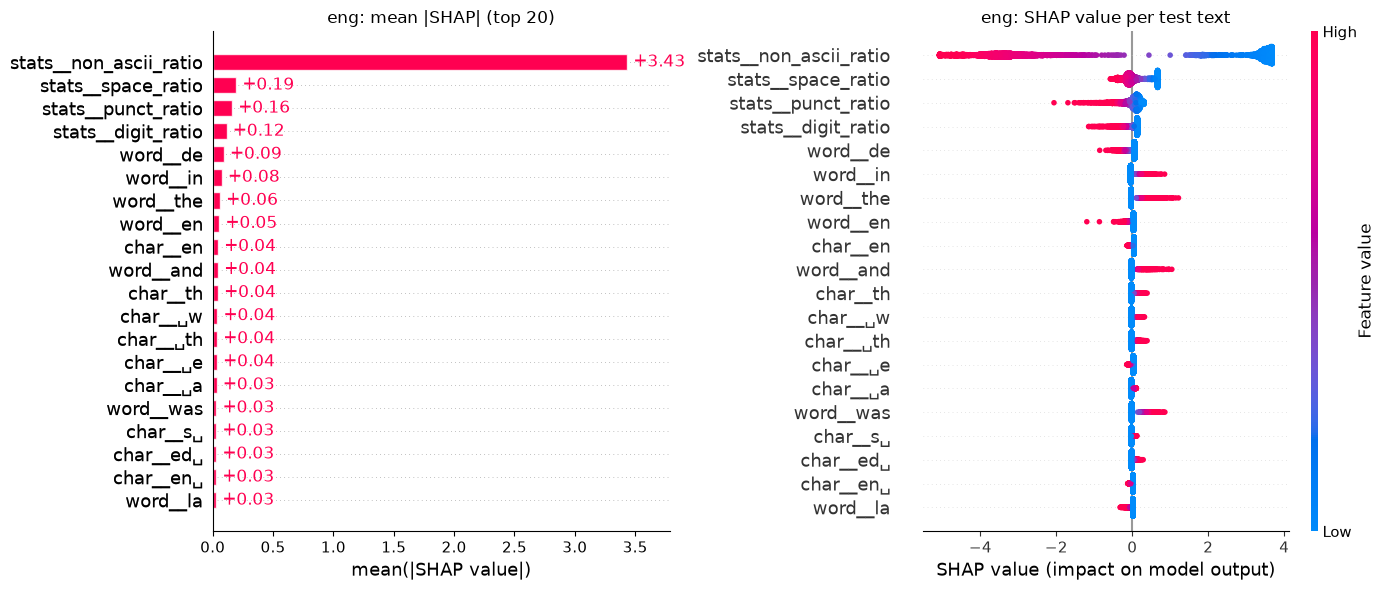

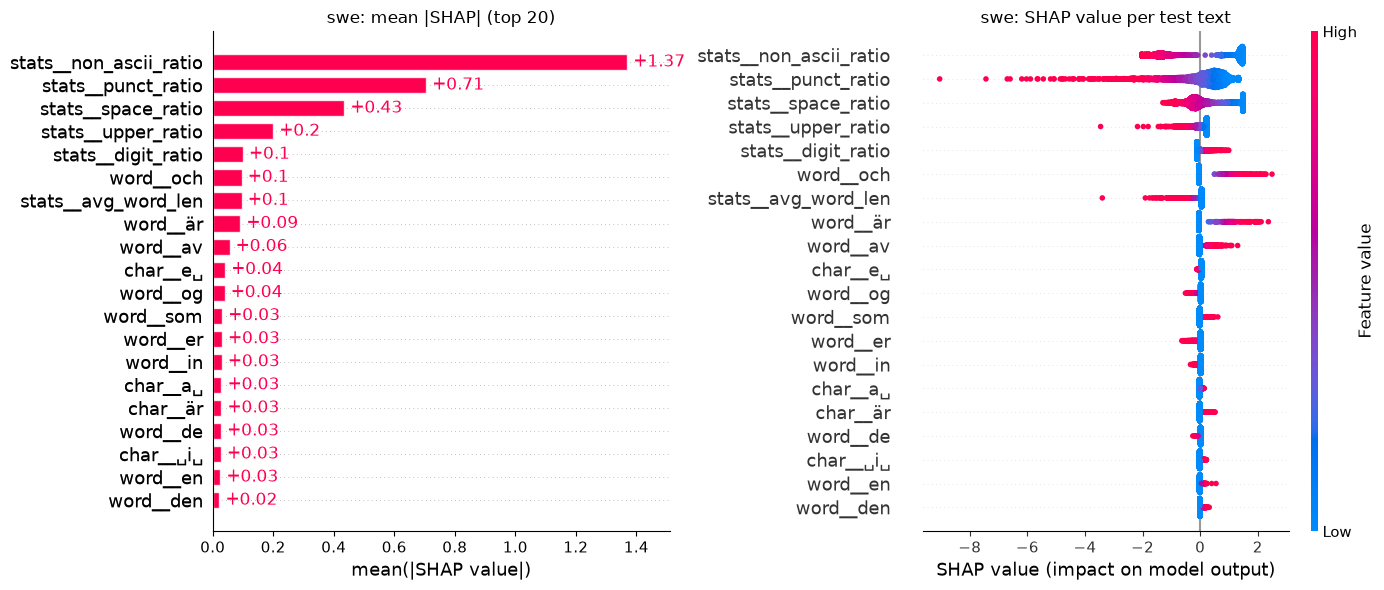

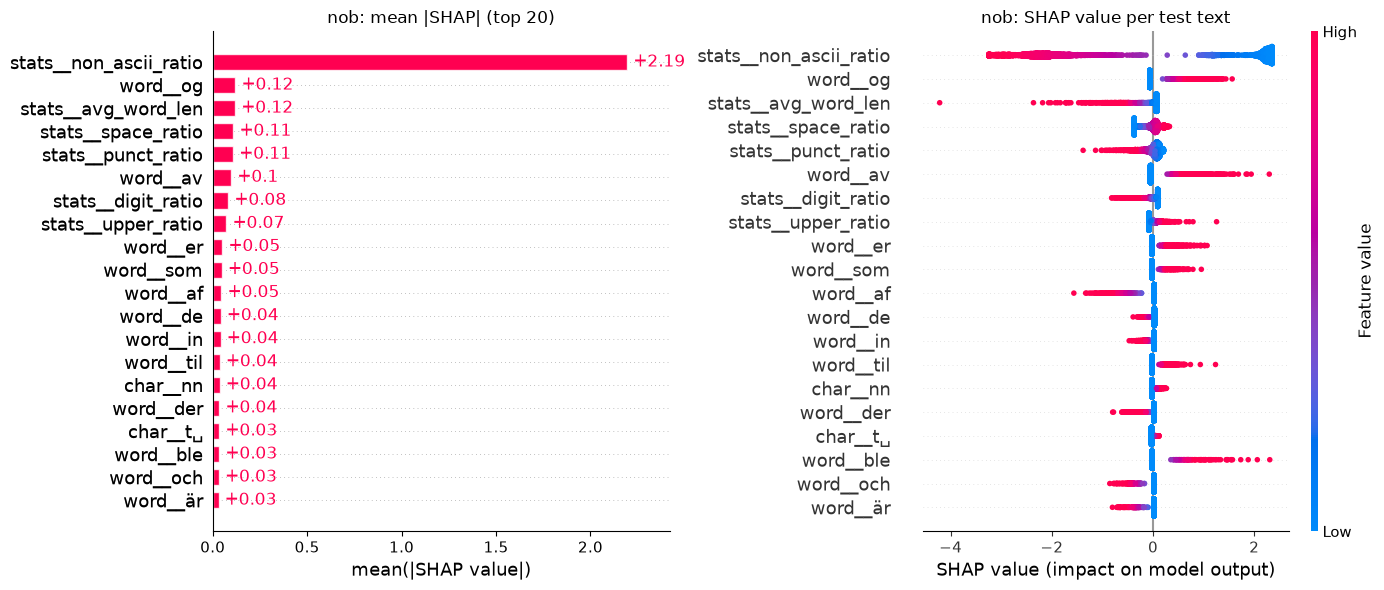

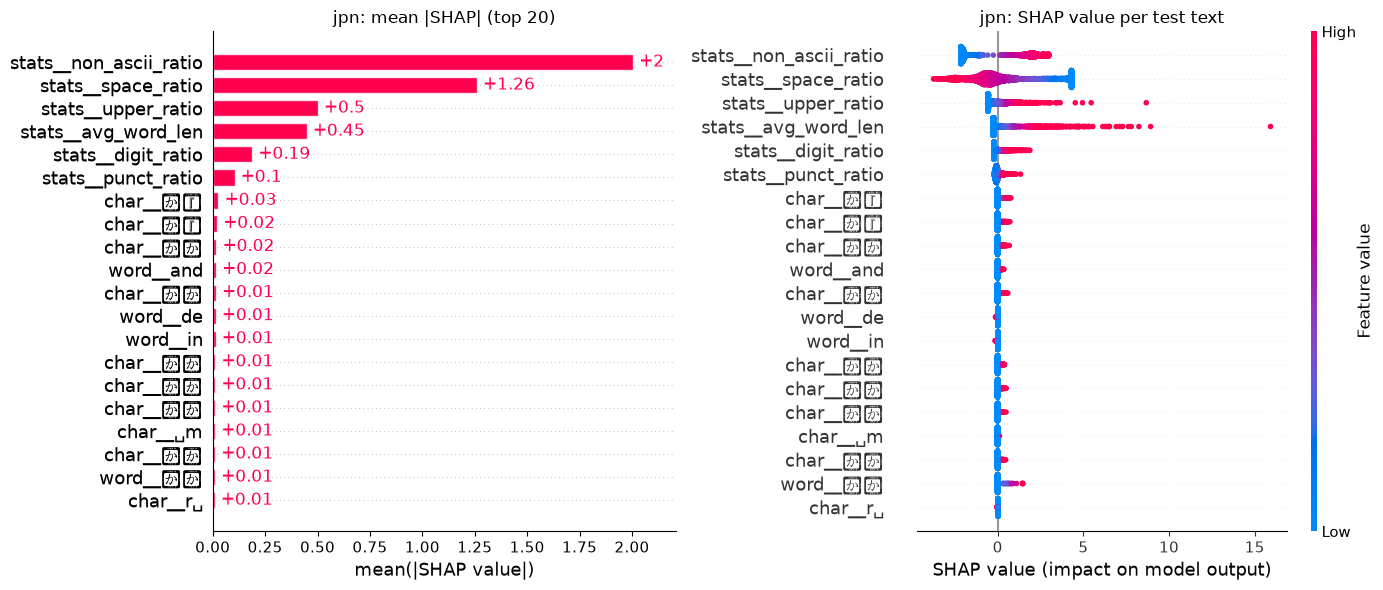

,eng,swe,nob,jpn
1,- stats__non_ascii_ratio,- stats__non_ascii_ratio,- stats__non_ascii_ratio,+ stats__non_ascii_ratio
2,- stats__space_ratio,- stats__punct_ratio,+ word__og,- stats__space_ratio
3,- stats__punct_ratio,- stats__space_ratio,- stats__avg_word_len,+ stats__upper_ratio
4,- stats__digit_ratio,- stats__upper_ratio,+ stats__space_ratio,+ stats__avg_word_len
5,- word__de,+ stats__digit_ratio,- stats__punct_ratio,+ stats__digit_ratio
6,+ word__in,+ word__och,+ word__av,+ stats__punct_ratio
7,+ word__the,- stats__avg_word_len,- stats__digit_ratio,+ char__る。
8,- word__en,+ word__är,+ stats__upper_ratio,+ char__た。
9,- char__en,+ word__av,+ word__er,+ char__して
10,+ word__and,- char__e␣,+ word__som,+ word__and


In [49]:
# importance = mean |SHAP value| over all test texts for that language's score (logit);
# the bar plots and beeswarm plots are made with shap, using shap.LinearExplainer on the top features
languages_to_inspect = ['eng', 'swe', 'nob', 'jpn']
n_top = 20

def explain_language(language, n_top=n_top):
    k = list(label_encoder.classes_).index(language)
    top = np.argsort(mean_abs_shap.loc[language].to_numpy())[::-1][:n_top]
    # with a linear model each feature's SHAP value only depends on its own weight and mean,
    # so explaining just the top features gives exactly the same values as explaining all of them
    explainer = shap.LinearExplainer((classifier.coef_[k, top], classifier.intercept_[k]),
                                     shap.maskers.Independent(feature_means[top].reshape(1, -1)))
    explanation = explainer(X_test_features[:, top].toarray())
    explanation.feature_names = list(feature_names[top])
    return explanation, top

top_features = {}
for language in languages_to_inspect:
    explanation, top = explain_language(language)
    k = list(label_encoder.classes_).index(language)
    top_features[language] = pd.DataFrame({
        'feature': feature_names[top],
        'mean_abs_shap': mean_abs_shap.loc[language].to_numpy()[top],
        'weight': classifier.coef_[k, top],          # > 0: evidence FOR this language, < 0: evidence AGAINST
    })

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    shap.plots.bar(explanation, max_display=n_top, show=False, ax=ax1)
    ax1.set_title(f"{language}: mean |SHAP| (top {n_top})")
    plt.sca(fig.add_subplot(1, 2, 2))
    shap.plots.beeswarm(explanation, max_display=n_top, show=False, plot_size=None)
    plt.title(f"{language}: SHAP value per test text")
    plt.tight_layout()
    plt.show()

# the same top-20 lists side by side ('+' = pushes towards the language, '-' = pushes away from it)
pd.DataFrame({
    language: [f"{'+' if w > 0 else '-'} {f}" for f, w in zip(df['feature'], df['weight'])]
    for language, df in top_features.items()
}, index=range(1, n_top + 1))

We can also look at the contribution of each type of feature:
1. char vectorizer
2. word vectorizer
3. stats features

By using mean |SHAP|, we can see that the contributions of char features and stats features are roughly equal. (note that we have 50000 char features, and only 6 stats features) 

In [50]:
# (a) share of the total mean |SHAP| that comes from each feature block, per language
block_importance = mean_abs_shap.T.groupby(feature_block).sum().T
block_share = block_importance.div(block_importance.sum(axis=1), axis=0)
block_share.loc['all languages (mean)'] = block_share.mean()
print("Share of total importance (mean |SHAP|) per feature block:")
display(block_share.loc[languages_to_inspect + ['all languages (mean)']].round(3))

# (b) how important is each extra feature individually? its rank among all features (1 = most important)
ranks = mean_abs_shap.rank(axis=1, ascending=False).astype(int)
stats_columns = list(feature_names[feature_block == 'stats'])
print(f"Rank of each TextStats feature among all {len(feature_names)} features:")
display(ranks.loc[languages_to_inspect, stats_columns])

Share of total importance (mean |SHAP|) per feature block:


,char,stats,word
eng,0.476,0.391,0.133
swe,0.452,0.388,0.160
nob,0.553,0.284,0.164
jpn,0.357,0.592,0.051
all languages (mean),0.417,0.478,0.105


Rank of each TextStats feature among all 100006 features:


,stats__avg_word_len,stats__space_ratio,stats__upper_ratio,stats__digit_ratio,stats__punct_ratio,stats__non_ascii_ratio
eng,128,2,766,4,3,1
swe,7,3,4,5,2,1
nob,3,4,8,7,5,1
jpn,4,2,3,5,6,1


However, we can also look at the contribution in terms of accuracy (unlike above where we look at how much it moves the prediction), surprisingly the model without stats features perform better.

In [51]:
# SHAP shows how much a feature moves the score, not whether the model needs it: if another block carries the
# same information, removing a feature costs nothing. so we retrain without each block (and with each block alone)
# and compare the cross-validated accuracy (same 3 folds as before)
blocks = dict(interp_model.named_steps['vect'].transformer_list)
ablation_settings = {
    'word + char + stats (all)': ['word', 'char', 'stats'],
    'without stats (= best model)': ['word', 'char'],
    'without word': ['char', 'stats'],
    'without char': ['word', 'stats'],
    'stats only': ['stats'],
}

ablation_rows = []
for setting, used_blocks in ablation_settings.items():
    model = clone(interp_model)
    model.named_steps['vect'].transformer_list = [(name, clone(blocks[name])) for name in used_blocks]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        scores = cross_val_score(model, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    ablation_rows.append({'setting': setting, 'cv_accuracy': scores.mean(), 'std': scores.std()})
pd.DataFrame(ablation_rows).set_index('setting').round(4)

,cv_accuracy,std
setting,,
word + char + stats (all),0.9892,0.0004
without stats (= best model),0.9897,0.0005
without word,0.9887,0.0003
without char,0.9695,0.0005
stats only,0.5968,0.0024


We can also look at the contributions of features to the prediction on correctly predicted examples, and incorrectly predicted examples

[test text 10] true=eng, predicted=eng, explaining the score of 'eng'
  Schyrleus also included a map of the Moon in Oculus Enoch et Eliae. It was the first depiction of the Moon as seen in an inverting telescope (and thus the Moon itself is inverted in the illustration, ...


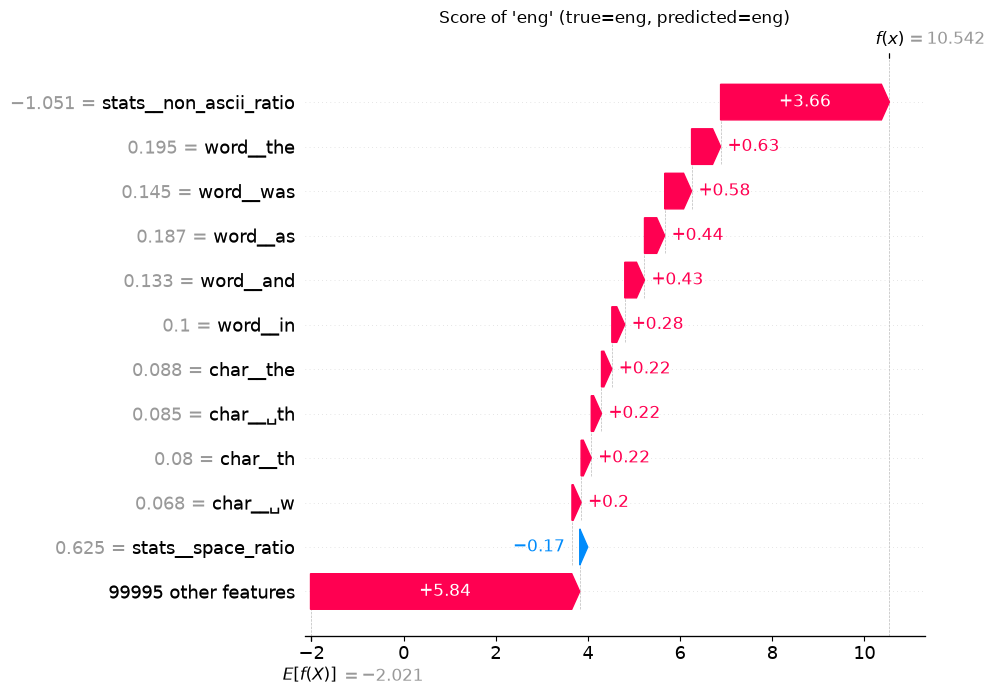

[test text 29] true=swe, predicted=swe, explaining the score of 'swe'
  Terrängen runt Klisurska sedlovina är huvudsakligen kuperad, men åt sydväst är den bergig. Den högsta punkten i närheten är 1 134 meter över havet, 1,0 km sydost om Klisurska sedlovina. Närmaste störr...


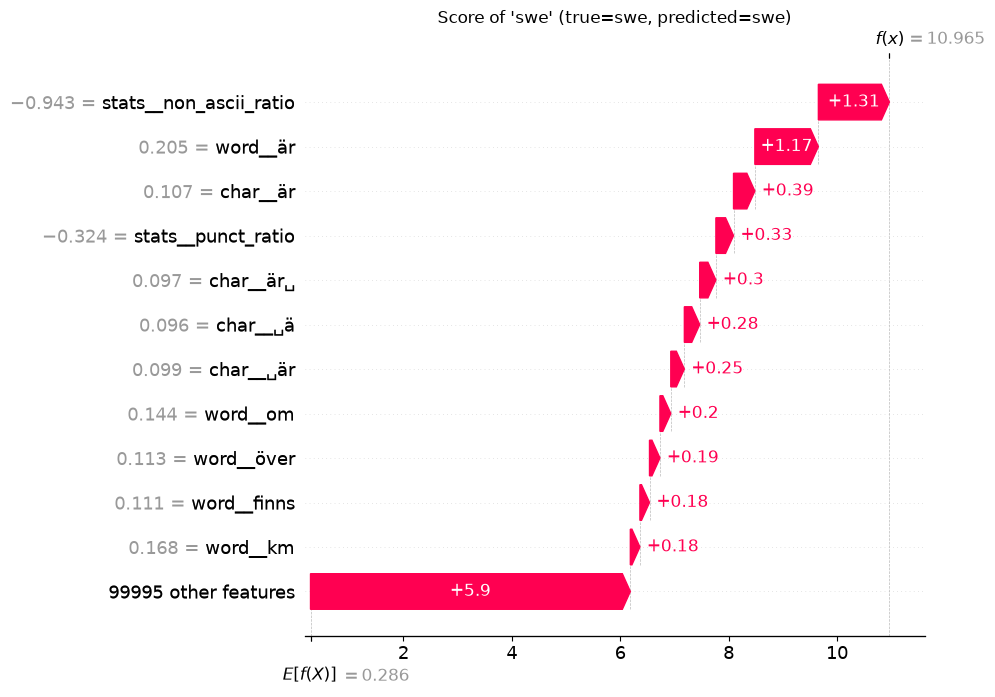

[test text 28] true=nob, predicted=nob, explaining the score of 'nob'
  I forbindelse med vinter-OL fikk Torino et nytt tunnelbanesystem. Det er foreløpig (januar 2006) bygget én linje, som begynner ved jernbanestasjonen Porta Nuova, går via sentrum og jernbanestasjonen P...


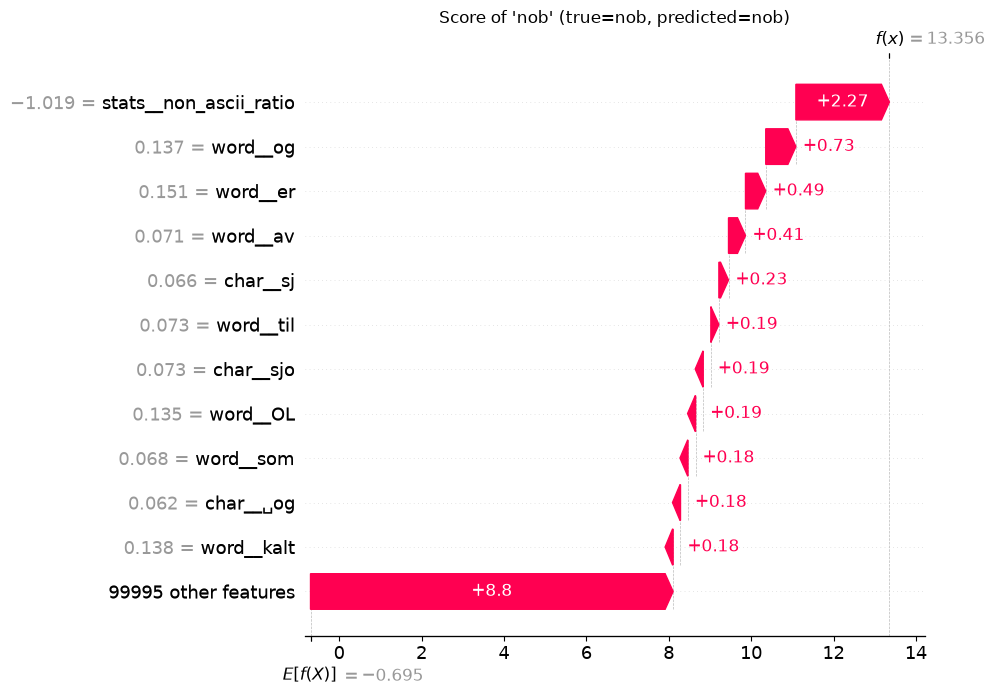

[test text 3] true=jpn, predicted=jpn, explaining the score of 'jpn'
  戦後、沿線の下総台地にあった陸軍施設が軍隊解散とともに民間施設に転用された。中でも千葉・津田沼には鉄道連隊が設置され、演習線が津田沼を起点に千葉・松戸に延びていた。この演習線跡地に目を付けた京成電鉄は仮称・下総電鉄を設立して、連合軍総司令部 (GHQ)・運輸省への払い下げ交渉を開始した。西武鉄道との激しい競合の末に1946年（昭和21年）3月に転用許可を、8月には路線免許を獲得。10月には正式に新...


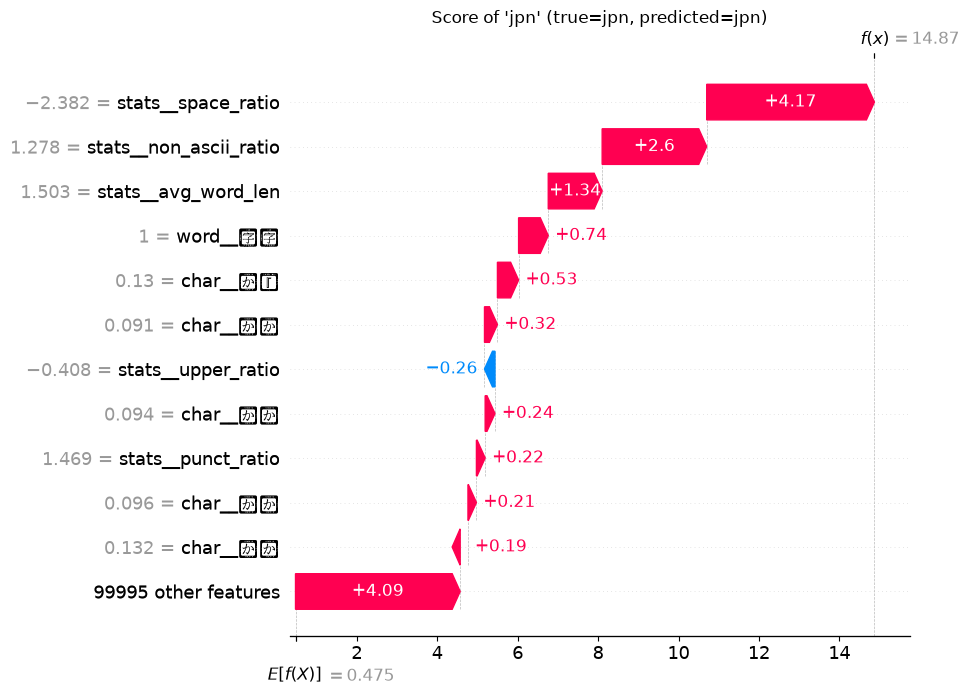

[test text 73] true=asm, predicted=eng, explaining the score of 'eng'
  Tailorbirds are found in singly or in pairs, usually low in the undergrowth or trees sometimes hopping on the ground. They forage for insects and have been known to feed on a range of beetles and bugs...


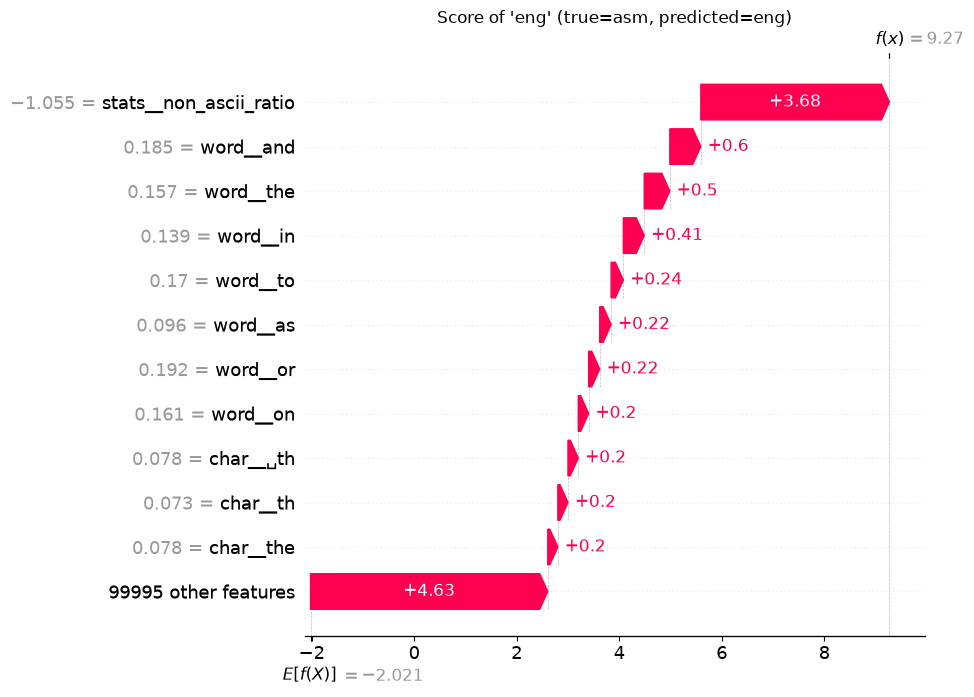

[test text 73] true=asm, predicted=eng, explaining the score of 'asm'
  Tailorbirds are found in singly or in pairs, usually low in the undergrowth or trees sometimes hopping on the ground. They forage for insects and have been known to feed on a range of beetles and bugs...


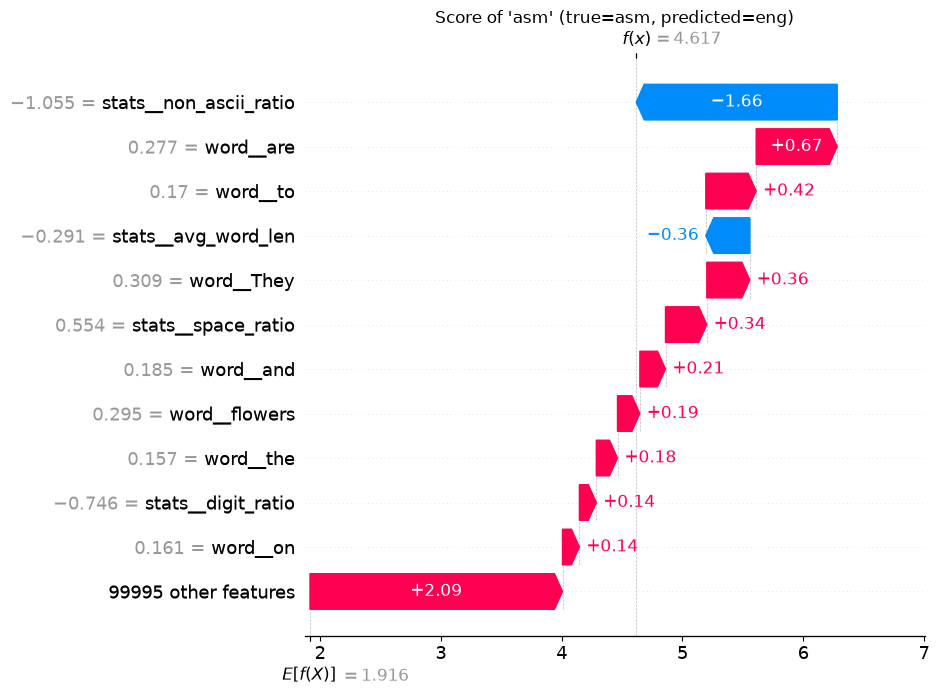

[test text 74] true=vie, predicted=nob, explaining the score of 'nob'
  1945, A History of Western Philosophy and Its Connection with Political and Social Circumstances from the Earliest Times to the Present Day, New York: Simon and Schuster.


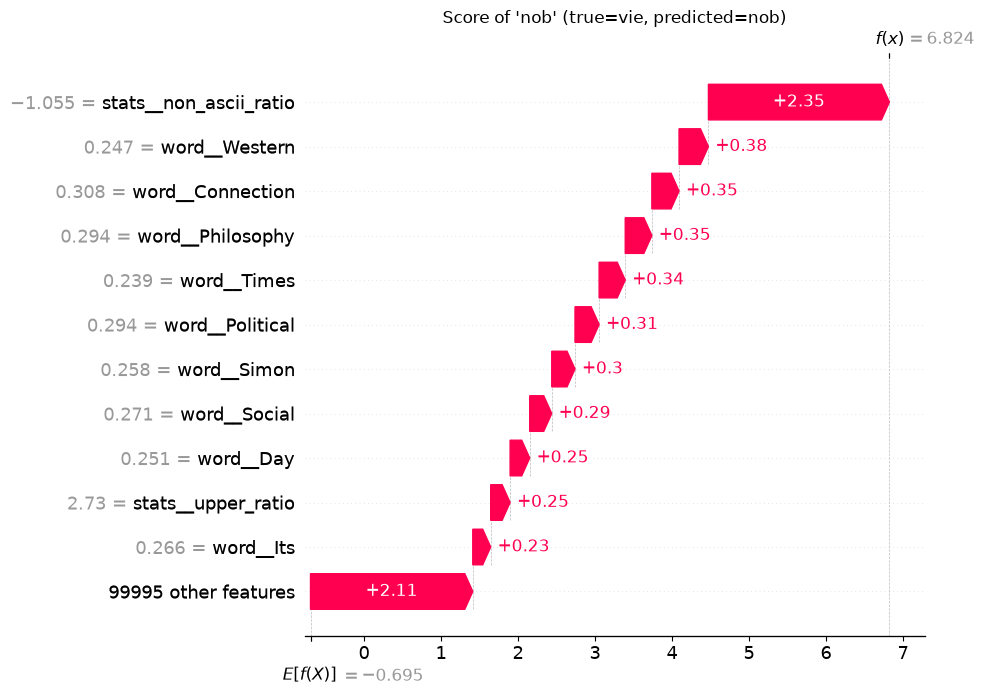

[test text 74] true=vie, predicted=nob, explaining the score of 'vie'
  1945, A History of Western Philosophy and Its Connection with Political and Social Circumstances from the Earliest Times to the Present Day, New York: Simon and Schuster.


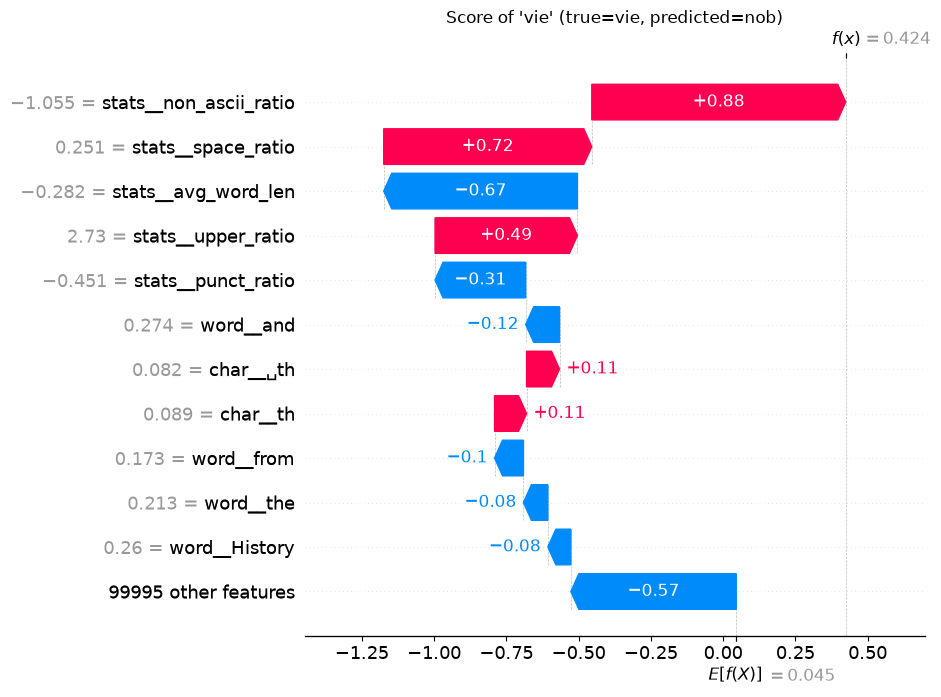

In [52]:
# a waterfall plot explains ONE prediction: it starts at the base value E[f(x)] (the score of an average
# training text for that language) and each bar shows how much one feature pushes the score up (red) or down (blue)
# for this text, ending at the model's actual score f(x). the score is the logit of the language, not a probability.
X_test_rows = X_test_features.tocsr()
interp_pred = classifier.predict(X_test_rows)
class_names = list(label_encoder.classes_)

def explain_text(i, language):
    """exact SHAP values of all features for test text i and the score of `language`"""
    k = class_names.index(language)
    x = X_test_rows[i].toarray().ravel()
    explanation = shap.Explanation(
        values=classifier.coef_[k] * (x - feature_means),
        base_values=classifier.coef_[k] @ feature_means + classifier.intercept_[k],
        data=x,
        feature_names=list(feature_names),
    )
    # sanity check: base value + all SHAP values = the model's score for this text
    assert np.isclose(explanation.base_values + explanation.values.sum(), classifier.decision_function(X_test_rows[i])[0, k])
    return explanation

def plot_waterfall(i, language, max_display=12):
    true_label, predicted_label = class_names[y_test[i]], class_names[interp_pred[i]]
    text = x_test.iloc[i]
    print(f"[test text {i}] true={true_label}, predicted={predicted_label}, explaining the score of '{language}'")
    print(f"  {text[:200]}{'...' if len(text) > 200 else ''}")
    shap.plots.waterfall(explain_text(i, language), max_display=max_display, show=False)
    plt.title(f"Score of '{language}' (true={true_label}, predicted={predicted_label})")
    plt.show()

# one correctly classified text for each of the four languages
for language in languages_to_inspect:
    k = class_names.index(language)
    i = np.flatnonzero((y_test == k) & (interp_pred == k))[0]
    plot_waterfall(i, language)

# a few misclassified texts: why did the predicted language win over the true one?
n_misclassified = 2
for i in np.flatnonzero(y_test != interp_pred)[:n_misclassified]:
    plot_waterfall(i, class_names[interp_pred[i]])   # score of the (wrong) predicted language
    plot_waterfall(i, class_names[y_test[i]])        # score of the true language

We can also look at coefficients in tbe LogisticRegression model itself
- this gives similar result to the SHAP values

In [ ]:
# for a linear model, coef_[k, j] is how much the score (logit) of language k changes when feature j increases by 1.
# raw coefficients are NOT comparable between features on different scales: a tf-idf value is ~0.01-0.3, while the
# standardised TextStats features have std 1. standardised coefficients (coef * std of the feature) fix this:
# the change in score when the feature moves by one standard deviation.

feature_std = np.sqrt(np.asarray(X_train_features.multiply(X_train_features).mean(axis=0)).ravel() - feature_means ** 2)
coef = pd.DataFrame(classifier.coef_, index=class_names, columns=feature_names)
importance_methods = {
    'raw coef': coef,
    'coef × std': coef * feature_std,
    'SHAP': mean_abs_shap * np.sign(coef),   # mean |SHAP| with the sign of the weight, for the +/- labels
}

def top_features_by(scores, language, n=n_top):
    row = scores.loc[language]
    return row[row.abs().sort_values(ascending=False).index[:n]]

top_by_method = {(language, method): top_features_by(scores, language)
                 for language in languages_to_inspect for method, scores in importance_methods.items()}

# how many of the top 20 features does each method share with SHAP?
print(f"Overlap with the SHAP top {n_top}:")
for language in languages_to_inspect:
    shap_top = set(top_by_method[(language, 'SHAP')].index)
    overlaps = {method: len(shap_top & set(top_by_method[(language, method)].index)) for method in ['raw coef', 'coef × std']}
    print(f"  {language}: raw coef {overlaps['raw coef']}/{n_top}, coef × std {overlaps['coef × std']}/{n_top}")

# side by side ('+' = evidence for the language, '-' = evidence against it)
pd.DataFrame({key: [f"{'+' if value > 0 else '-'} {feature}" for feature, value in top.items()]
              for key, top in top_by_method.items()}, index=range(1, n_top + 1))

Overlap with the SHAP top 20:
  eng: raw coef 10/20, coef × std 16/20
  swe: raw coef 4/20, coef × std 16/20
  nob: raw coef 10/20, coef × std 18/20
  jpn: raw coef 8/20, coef × std 17/20


eng                            \
                    raw coef                coef × std   
1                + word__was  - stats__non_ascii_ratio   
2   - stats__non_ascii_ratio      - stats__punct_ratio   
3                + word__the      - stats__space_ratio   
4                 + char__␣w      - stats__digit_ratio   
5                + word__and               + word__the   
6                 + word__in                - word__de   
7                 + char__th                + word__in   
8                + char__␣th               + word__and   
9                + char__the               + word__was   
10               + char__ed␣                - word__en   
11                - word__de                + char__th   
12               + char__␣a␣                + char__␣w   
13               + word__who               + char__␣th   
14                + word__as               + char__the   
15              + word__were                - word__og   
16                + word__he                - char__en   
17               + word__his                - word__la   
18          - word__election               + word__for   
19              + word__born               + char__ed␣   
20                + word__an                + word__as   

                                       swe                            \
                        SHAP      raw coef                coef × std   
1   - stats__non_ascii_ratio   + word__och  - stats__non_ascii_ratio   
2       - stats__punct_ratio    + word__är      - stats__punct_ratio   
3       - stats__space_ratio    + char__är      - stats__space_ratio   
4       - stats__digit_ratio    + word__av                + word__är   
5                 - word__de   + char__är␣               + word__och   
6                 + word__in  + word__till     - stats__avg_word_len   
7                + word__the    + char__␣ä      - stats__upper_ratio   
8                 - word__en   + char__␣oc      + stats__digit_ratio   
9                 - char__en    + char__ör                + word__av   
10                + char__th    + char__fö                - word__og   
11               + word__and   + char__och                + char__är   
12                + char__␣w   + char__␣är                - word__er   
13               + char__␣th   + char__␣fö               + word__som   
14                - char__␣e  + word__från               + char__är␣   
15                + char__␣a   + word__att                + char__␣ä   
16               + word__was  + word__född              + word__till   
17                - word__la   + word__ett               + char__␣är   
18               + char__ed␣   + char__för                - word__in   
19                + char__s␣   + word__för               + word__den   
20               - char__en␣    + char__oc                - char__e␣   

                                       nob                            \
                        SHAP      raw coef                coef × std   
1   - stats__non_ascii_ratio    + word__av  - stats__non_ascii_ratio   
2       - stats__punct_ratio   + word__ble     - stats__avg_word_len   
3       - stats__space_ratio    + word__og                + word__og   
4       - stats__upper_ratio    - word__af      + stats__space_ratio   
5      - stats__avg_word_len    + char__sj                + word__av   
6       + stats__digit_ratio    + word__er                - word__af   
7                + word__och  - word__blev      - stats__punct_ratio   
8                 + word__är    + char__nn               + word__ble   
9                 + word__av   + char__␣og                + word__er   
10                - char__e␣   + word__seg      - stats__digit_ratio   
11                - word__og   + word__som               + word__som   
12               + word__som   + char__av␣                - word__är   
13                - word__in   + char__␣av               - word__och   
14                - word__er   + word__til               + word__til   
15         

---

### 6.1 Ablation Study

Lastly, we want to conduct a small ablation study to investigate how well our model performs under different conditions.

As a first step, choose the two languages for which the classifier worked best.

Next, re-fit the best model six times, each time reducing the **length** of each instance in the training set. To do this, create a custom `TextReducer` class that you can include as a preprocessing step in your pipeline. The class should take a `max_len` argument as a hyperparameter that can be set to train the following models:

- Model 1: `max_len = None` (i.e. no truncation!)
- Model 2: `max_len = 500`
- Model 3: `max_len = 250`
- Model 4: `max_len = 150`
- Model 5: `max_len = 100`
- Model 6: `max_len = 50`

Use average accuracy over the cross validation scores for each model to measure performance for each ablation setting.

📝❓ How does the reduction of training data affect the performance of the classifier? And what could be some possible reasons for this?

How does the reduction of training data affect performance?
- in general, it reduce the accuracy. Because, the same n-gram can exist in several languages. The more we observe in an example text, the more confident the model becomes. If we have a lot training data, it shouldn't be much of a problem.  However, the accuracy would drop significantly if we also predict on a shorter text.
- in the case of languages that are non similar to one another, this is not a big problem
- in the case of languages that inherit from the same root, it can hurt the performance more

Option 1: pick 2 languages
- the classifier worked best: ara (Arabic) and kan (Kannada)
- the similar languages pair: dan (Danish) and nob (Norwegian Bokmål)

In [53]:
# TODO: Ablation study
from sklearn.metrics import f1_score

per_language_f1 = (pd.Series(f1_score(y_test, y_pred, average=None), index=label_encoder.classes_)
                   .sort_values(ascending=False, kind='stable'))
best_two = list(per_language_f1.index[:2])
print(per_language_f1.head(6).round(4).to_string())
print(f"\nBest two languages: {best_two}")

ara    1.0000
kan    1.0000
heb    0.9975
kor    0.9975
swe    0.9975
nob    0.9950

Best two languages: ['ara', 'kan']


In [54]:
# TextReducer, a preprocessing step that truncates each text to its first `max_len` characters
from sklearn.base import BaseEstimator, TransformerMixin

class TextReducer(BaseEstimator, TransformerMixin):
    """Truncate every text to its first `max_len` characters (max_len=None: keep the full text).

    Inside a Pipeline, fit() calls fit_transform() on the training texts and predict() calls transform()
    on the texts to predict. So:
    - reduce_at_predict=False: only the training texts are truncated; we predict on full-length texts
      (this isolates the effect of reducing the *training data*, which is what the question asks)
    - reduce_at_predict=True: training and predicted texts are both truncated (short texts at test time too)
    """
    def __init__(self, max_len=None, reduce_at_predict=False):
        self.max_len = max_len
        self.reduce_at_predict = reduce_at_predict

    def _truncate(self, X):
        if self.max_len is None:
            return X
        return [text[:self.max_len] for text in X]

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y=None):
        return self._truncate(X)

    def transform(self, X):
        return self._truncate(X) if self.reduce_at_predict else X

In [55]:
# runs on the training texts of the chosen languages only; also runs a hard pair (dan / nob) for comparison,
# since two languages with different scripts may be perfectly separable at any length
import warnings
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

max_lens = [None, 500, 250, 150, 100, 50]
language_pairs = {'best two: ' + ' / '.join(best_two): best_two, 'hard pair: dan / nob': ['dan', 'nob']}

ablation_rows = []
for pair_name, languages in language_pairs.items():
    in_pair = np.isin(label_encoder.inverse_transform(y_train), languages)
    x_pair, y_pair = x_train[in_pair], y_train[in_pair]
    for reduce_at_predict in [False, True]:
        for max_len in max_lens:
            model = Pipeline([('reduce', TextReducer(max_len=max_len, reduce_at_predict=reduce_at_predict)),
                              *clone(final_model).steps])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', FutureWarning)   # 'penalty' deprecation warning
                scores = cross_val_score(model, x_pair, y_pair, cv=5, scoring='accuracy')
            ablation_rows.append({
                'pair': pair_name,
                'truncated': 'train + predict' if reduce_at_predict else 'train only',
                'max_len': 'None' if max_len is None else max_len,
                'texts_truncated': np.mean(x_pair.str.len() > max_len) if max_len else 0.0,
                'cv_accuracy': scores.mean(),
                'std': scores.std(),
            })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.pivot_table(index='max_len', columns=['pair', 'truncated'], values='cv_accuracy', sort=False).round(4)

pair      best two: ara / kan                 hard pair: dan / nob  \
truncated          train only train + predict           train only   
max_len                                                              
None                   0.9981          0.9981               0.9925   
500                    0.9981          0.9981               0.9925   
250                    0.9981          0.9981               0.9919   
150                    0.9981          0.9981               0.9919   
100                    0.9981          0.9981               0.9894   
50                     0.9981          0.9969               0.9887   

pair                       
truncated train + predict  
max_len                    
None               0.9925  
500                0.9925  
250                0.9912  
150                0.9788  
100                0.9556  
50                 0.9056

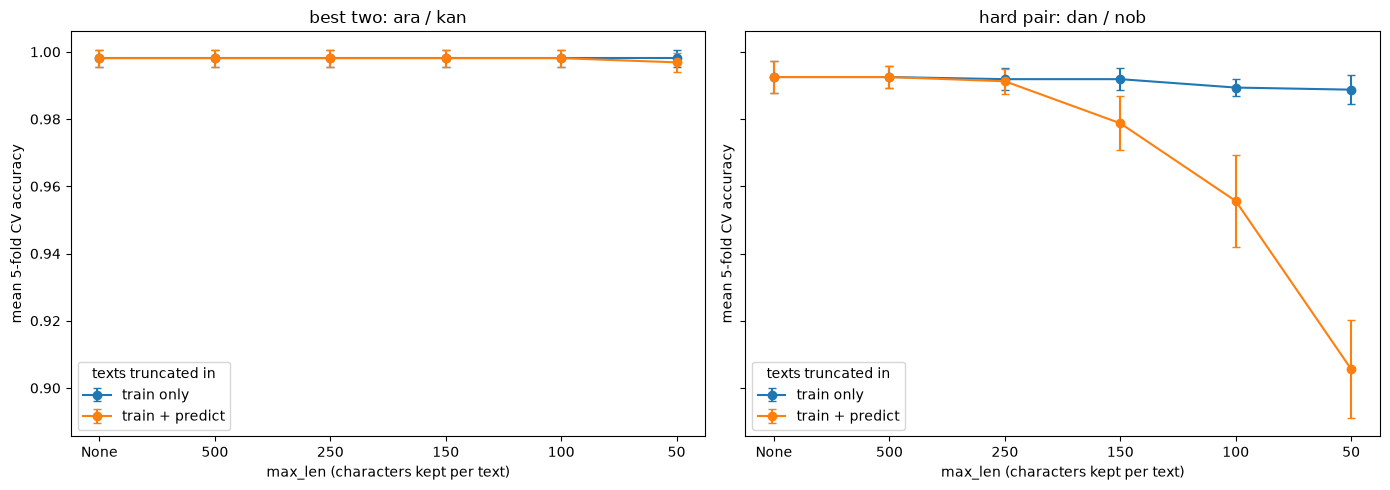

Training text length: min 140, median 299, 90th percentile 714, max 7353


In [56]:
# plot accuracy vs max_len
fig, axes = plt.subplots(1, len(language_pairs), figsize=(14, 5), sharey=True)   # same y-axis, so both pairs are comparable
for ax, pair_name in zip(np.atleast_1d(axes), language_pairs):
    for truncated, group in ablation_results[ablation_results['pair'] == pair_name].groupby('truncated', sort=False):
        ax.errorbar(group['max_len'].astype(str), group['cv_accuracy'], yerr=group['std'], marker='o', capsize=3, label=truncated)
    ax.set_title(pair_name)
    ax.set_xlabel('max_len (characters kept per text)')
    ax.set_ylabel('mean 5-fold CV accuracy')
    ax.legend(title='texts truncated in')
plt.tight_layout()
plt.show()

# how long are the texts in the first place? (how much does each max_len actually remove)
text_lengths = x_train.str.len()
print(f"Training text length: min {text_lengths.min()}, median {text_lengths.median():.0f}, "
      f"90th percentile {text_lengths.quantile(0.9):.0f}, max {text_lengths.max()}")

We can also look at all 20 languages together

In [57]:
# cross_val_predict gives one out-of-fold prediction for every training text (5 folds), so for every max_len we can
# compute accuracy, macro precision / recall / F1 and the F1 of each language
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

all_language_model = clone(final_model)

macro_rows = []
per_language_f1_by_setting = {}
for reduce_at_predict in [False, True]:
    truncated = 'train + predict' if reduce_at_predict else 'train only'
    for max_len in max_lens:
        model = Pipeline([('reduce', TextReducer(max_len=max_len, reduce_at_predict=reduce_at_predict)),
                          *clone(all_language_model).steps])
        cv_pred = cross_val_predict(model, x_train, y_train, cv=5, n_jobs=-1)

        max_len_name = 'None' if max_len is None else max_len
        precision, recall, f1, _ = precision_recall_fscore_support(y_train, cv_pred, average='macro')
        macro_rows.append({'truncated': truncated, 'max_len': max_len_name, 'accuracy': accuracy_score(y_train, cv_pred),
                           'macro_precision': precision, 'macro_recall': recall, 'macro_f1': f1})
        per_language_f1_by_setting[(truncated, max_len_name)] = f1_score(y_train, cv_pred, average=None)

macro_results = pd.DataFrame(macro_rows)
# rows: languages, columns: (truncated, max_len)
per_language_f1_all = pd.DataFrame(per_language_f1_by_setting, index=label_encoder.classes_)
macro_results.round(4)

,truncated,max_len,accuracy,macro_precision,macro_recall,macro_f1
0,train only,None,0.9899,0.9905,0.9899,0.9900
1,train only,500,0.9899,0.9905,0.9899,0.9901
2,train only,250,0.9896,0.9902,0.9896,0.9897
3,train only,150,0.9888,0.9895,0.9888,0.9890
4,train only,100,0.9877,0.9885,0.9877,0.9879
5,train only,50,0.9860,0.9871,0.9860,0.9862
6,train + predict,None,0.9899,0.9905,0.9899,0.9900
7,train + predict,500,0.9899,0.9905,0.9899,0.9901
8,train + predict,250,0.9896,0.9901,0.9896,0.9897
9,train + predict,150,0.9874,0.9881,0.9874,0.9876


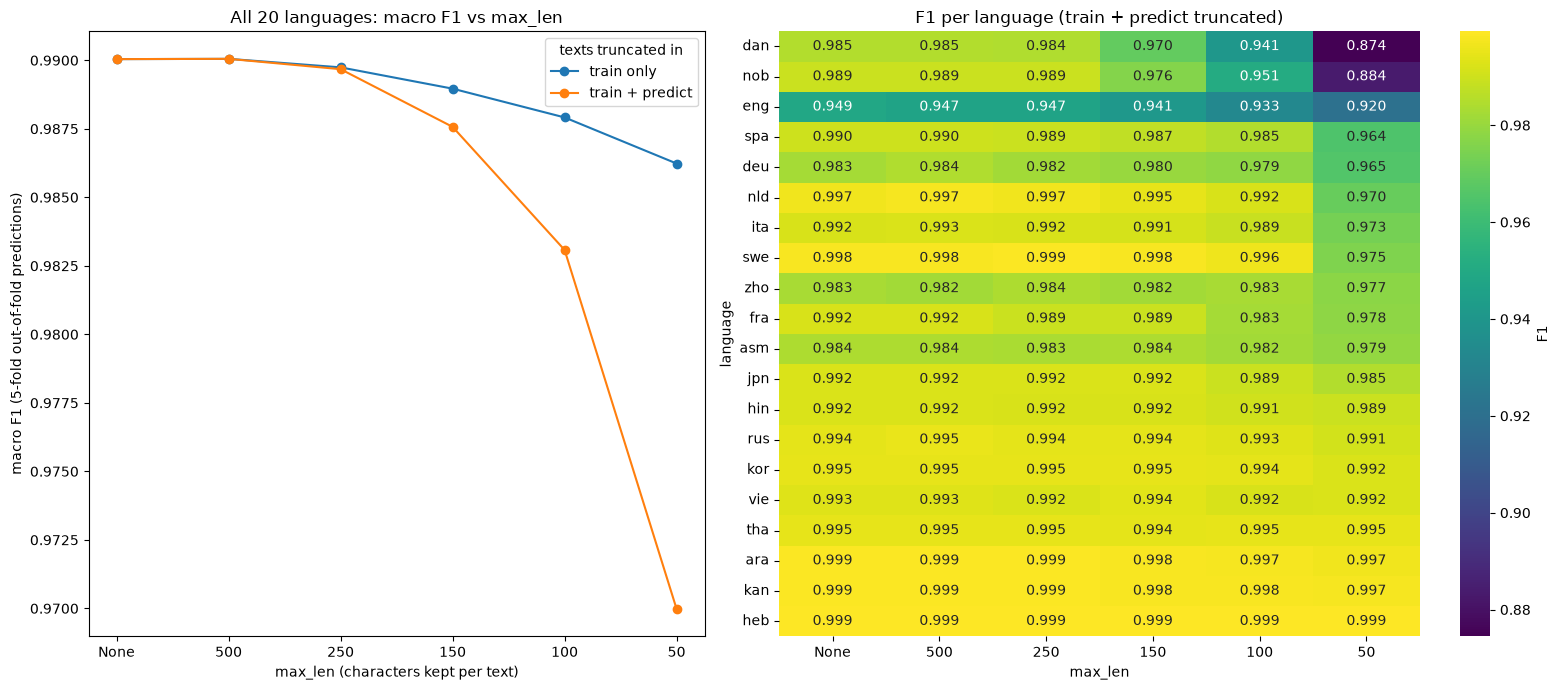

F1 drop from full texts to max_len=50 (largest first):


,train only,train + predict
dan,0.0057,0.1104
nob,0.0044,0.1058
eng,0.0219,0.0285
nld,0.0082,0.0266
spa,0.0026,0.0256
swe,0.0006,0.0230
ita,0.0038,0.0188
deu,0.0082,0.0172
fra,0.0129,0.0137
jpn,0.0019,0.0076


In [58]:
# left: macro F1 vs max_len for both variants; right: F1 of every language when the predicted texts are truncated too
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.3]})

for truncated, group in macro_results.groupby('truncated', sort=False):
    ax1.plot(group['max_len'].astype(str), group['macro_f1'], marker='o', label=truncated)
ax1.set_title('All 20 languages: macro F1 vs max_len')
ax1.set_xlabel('max_len (characters kept per text)')
ax1.set_ylabel('macro F1 (5-fold out-of-fold predictions)')
ax1.legend(title='texts truncated in')

f1_short_texts = per_language_f1_all['train + predict']
f1_short_texts = f1_short_texts.sort_values(f1_short_texts.columns[-1])   # languages hurt most by short texts on top
sns.heatmap(f1_short_texts, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'F1'}, ax=ax2)
ax2.set_title('F1 per language (train + predict truncated)')
ax2.set_xlabel('max_len')
ax2.set_ylabel('language')
plt.tight_layout()
plt.show()

# biggest drop in F1 between full texts and 50 characters, per variant
f1_drop = pd.DataFrame({
    truncated: per_language_f1_all[(truncated, 'None')] - per_language_f1_all[(truncated, 50)]
    for truncated in ['train only', 'train + predict']
}).sort_values('train + predict', ascending=False)
print("F1 drop from full texts to max_len=50 (largest first):")
f1_drop.round(4).head(10)

---

## Lab report

📝❓ Write your lab report here, addressing all questions in the notebook. For convenience, the questions are collected below; please keep your answers clearly marked.

### Questions

**1.1 Exploring the training data**

- 📝❓ Do you notice anything that might be challenging for the classification?
  - Some labels appear incorrect which misleads the model during training. (For example, some text is entirely in English, while the label is some other different language)
  - There are closely related languages and dialects that share vocabulary and confuse the classifier. 
  - Some texts contain mixed languages making their true class ambiguous. 
  - Certain languages do not use spaces which breaks standard whitespace tokenization. 
  - Uneven text lengths make shorter texts harder to classify because they provide less context. 
  - The same text sometimes appears under different labels like ava and pcd causing conflicting training signals. 
  - Having 235 classes is difficult for a logistic regression model because the large number of categories makes it hard to find clear linear boundaries.

- 📝❓ How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)
  - The data is perfectly balanced because there are exactly 500 instances per label in both the training set and the test set. This equal distribution prevents the model from developing a bias toward any majority class. 
  - Both train and test sets also have roughly the same distributions in word count and character count (statistically tested) which shows the data properties are consistent across splits.

- 📝❓ Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.
  - The split is not appropriate because there is significant data overlap between the sets. There are 3147 test texts that also appear in the training set which leads to data leakage and artificially inflates evaluation scores. This overlap is highly concentrated in a few languages like che and hat. 
  - Also an equal split wastes training data because a smaller test set would be sufficient for evaluation while providing the model with more examples to learn from. Therefore, we clean the data by combining train+test sets first, dropping the duplicates, and spliting 80% as train and 20% as test set.


**3.2 Best Model Selection**

- 📝❓ What were the hyperparameters of your best-performing model according to cross-validation?
  - The best hyperparameter combination uses a maximum of 200000 features for the character vectorizer with an ngram range of 1 to 5. For the logistic regression model the best regularization strength C is 100 with L2-normalization and the newton-cg solver. These settings provide the optimal balance between capturing character patterns and penalizing overly complex models.

- 📝❓ What is the advantage of grid search cross-validation?
  - Grid search evaluates every possible combination of the specified hyperparameter values to guarantee finding the best one which is then retrained on the full training set. 
  - While cross-validation provides a more reliable performance score than a single validation split because every training example is used for validation exactly once. This ensures that hyperparameters are selected using only the training data so the final test score remains an unbiased estimate of performance on unseen data.


**3.3 Model Evaluation**

- 📝❓ According to standard metrics (e.g. Accuracy, Precision, Recall and F1), how well does your model perform on the held-out test set?
  - The model performs exceptionally well on the held-out test set with an overall accuracy of 0.9900 and an F1 score of 0.9902. These high scores indicate that the classifier successfully distinguishes between the 20 languages with very few mistakes across all categories.


**4.1 Error Analysis**

- 📝❓ Where does your model do well and where does it fail?
  - The model does well when the input texts are mostly written in a single language without too much foreign vocabulary. It performs poorly and tends to misclassify texts as English when the original label seems to be incorrect. This usually happens when the text is actually written in English but was mistakenly scraped from a web page categorized under a different language.

- 📝❓ What are some possible reasons for why it fails in these cases?
  - The main reason for these failures is noisy data where the ground truth labels are simply wrong. When a text contains mostly English words but is labeled as another language the model correctly predicts English based on the features but it counts as a failure because the dataset label is incorrect. Mixed language texts also confuse the model because they contain n-gram features from multiple languages which dilutes the strongest signal.


**5.1 Interpretability Analysis**

- 📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.
  - According to the SHAP values the extra statistical features appear to be more important for individual predictions because they can shift the model probability significantly. For example observing a high space count immediately rules out languages that do not use spaces. 
  - However the features from the character vectorizer are better overall predictors when combined together even though individual character n-grams do not carry as much weight alone. This is supported by the fact that the model actually achieves very poor accuracy when using statistical features alone, compared to using just features from vectorizer.


**6.1 Ablation Study**

- 📝❓ How does reducing the length of the training texts affect the performance of the classifier? And what could be some possible reasons for this?
  - Reducing the length of the training texts generally reduces the accuracy of the classifier. This happens because the same character n-grams can exist across several different languages. When the model observes longer texts it gathers more evidence and becomes more confident in its prediction. While length reduction is not a big problem for distinct languages, it significantly hurts performance for closely related languages that share a common root because the model needs more context to tell them apart.


## Declarations

Please fill in both declarations below by editing this cell (double-click it). Mark the applicable option by replacing ☐ with ☒ (copy the symbol from here: ☒) and complete the text field where required. Your reviewers will check that both declarations are present and completed.

### Contribution declaration

By submitting this work, the group declares that the contributions of the group members were:

☒ approximately equal

☐ not approximately equal

If the contributions were not approximately equal, no individual group member needs to be identified.

### Declaration on the use of AI

The group declares that any use of AI-based tools in preparing this work complied with the rules specified for this exercise.

☐ No AI-based tools were used.

☒ AI-based tools were used in accordance with the rules of the exercise.

If AI-based tools were used, briefly state the tool(s) used and the purpose(s) for which they were used:

We used Gemini for debugging and code verification.
